# 1. Loading the Libraries

In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

# ML Libraries
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score, log_loss, brier_score_loss

from scipy.optimize import minimize
from scipy.special import softmax

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
})

sns.set_context("notebook", font_scale=1.3)

# 2. Defining Functions and Algorithm

In [0]:
def self_consistency(predictions):
    B = predictions.shape[0]
    B1 = np.sum(predictions == 1)
    B0 = B - B1
    return 1 - (2* B0 * B1)/(B * (B - 1))

def ambiguity_score(predictions):
    B = predictions.shape[0]
    predictions_sum = np.sum(predictions, axis = 0)
    ambiguous_points = (predictions_sum != B) & (predictions_sum != 0)
    return np.mean(ambiguous_points)

def aggregate_with_abstention(predictions, kappa):
    sc = self_consistency(predictions)
    if sc >= kappa:
        values, counts = np.unique(predictions, return_counts=True)
        return {'prediction': values[np.argmax(counts)], 'self_consistency': sc}
    else:
        return {'prediction': "Abstain", 'self_consistency': sc}
    
def aggregate_prediction(predictions):
    values, counts = np.unique(predictions, return_counts=True)
    return values[np.argmax(counts)] 

def compute_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0)
    }

def prediction_summary(final_preds):
    total_datapoints = len(final_preds)
    abstained_count = np.sum(final_preds == "Abstain")
    predicted_count = total_datapoints - abstained_count
    print("---------------- Prediction Summary ----------------")
    print("Total Test data points:", total_datapoints)
    print("Predicted:", predicted_count)
    print("Abstained:", abstained_count)
    print("Abstention rate:", abstained_count / total_datapoints)
    print("----------------------------------------------------\n")

def performance_metrics(y_actual, y_pred, set_name):
    print("---------------- Perfomance Metrics ----------------")
    print(f"For {set_name}\n")
    print("Accuracy:")
    print(accuracy_score(y_actual, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_actual, y_pred))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_actual, y_pred))

    print("\n----------------------------------------------------\n")

In [0]:
def preprocess_split(X_train, X_test, num_features, cat_features):
    encoder = OneHotEncoder(drop = 'first', sparse_output = False)

    X_train_cat = encoder.fit_transform(X_train[cat_features])
    X_test_cat = encoder.transform(X_test[cat_features])

    X_train_num = X_train[num_features].values
    X_test_num = X_test[num_features].values

    X_train_processed = np.hstack((X_train_num, X_train_cat))
    X_test_processed = np.hstack((X_test_num, X_test_cat))

    return X_train_processed, X_test_processed

def get_model(model_type, random_state):
    if model_type == "Logistic Regression":
        return LogisticRegression(max_iter=1000, penalty = None, verbose=0)
    elif model_type == "Random Forest":
        return RandomForestClassifier(n_estimators=100, max_depth=None, random_state = random_state)
    elif model_type == "Decision Tree":
        return DecisionTreeClassifier(random_state = random_state)
    elif model_type == "Gradient Boosting":
        return GradientBoostingClassifier(random_state = random_state)
    return LogisticRegression(max_iter=1000, penalty = None)


### Defining the Cooper's Ensemble Algorithm

In [0]:
def ensemble_with_abstention(X_train, y_train, X_test, B_ensembles, SC_threshold, random_state, model_type):

    all_model_predictions = []

    np.random.seed(random_state)

    for i in range(B_ensembles):
        X_boot, y_boot = resample(
                X_train,
                y_train,
                replace=True,
                random_state = random_state + i
            )

        model = get_model(model_type, random_state)

        model.fit(X_boot, y_boot)
        preds = model.predict(X_test)
        all_model_predictions.append(preds)

    all_model_predictions = np.array(all_model_predictions)

    final_predictions_without_abstention = []
    final_predictions = []
    sc_scores = []

    for i in range(X_test.shape[0]):
        preds_for_point = all_model_predictions[:,i]
        pred_results_for_point = aggregate_with_abstention(preds_for_point, SC_threshold)
        final_pred = pred_results_for_point['prediction']
        final_predictions.append(final_pred)
        sc = pred_results_for_point['self_consistency']
        sc_scores.append(sc)
        pred_results_for_point_without_abstention = aggregate_prediction(preds_for_point)
        final_predictions_without_abstention.append(pred_results_for_point_without_abstention)


    return np.array(final_predictions), np.array(sc_scores), np.array(final_predictions_without_abstention), all_model_predictions
    # final_preds = np.array(final_predictions)
    # final_preds_without_abstention = np.array(final_predictions_without_abstention)
    # prediction_summary(np.array(final_predictions))
    # y_test_for_non_abstain_points = y_test.values[final_preds != "Abstain"]
    # y_preds_for_non_abstain_points = final_preds[final_preds != "Abstain"].astype(int)
    # performance_metrics(y_test_for_non_abstain_points, y_preds_for_non_abstain_points, "Non Abstained Points in Test set")
    # performance_metrics(y_test, final_preds_without_abstention, "Entire Test set")

### Running the Cooper's Ensemble Algorithm for n different train-test splits

In [0]:
def run_n_splits_experiment(df, features, target, num_features, cat_features, model_type, B_ensembles=101, SC_threshold= 0.75, n_splits= 10):
    results = []

    for split_seed in range(1, n_splits + 1):

        X_train, X_test, y_train, y_test = train_test_split(
            df[features],
            df[target],
            test_size = 0.2,
            random_state = split_seed
        )

        X_train_processed, X_test_processed = preprocess_split(
            X_train,
            X_test,
            num_features,
            cat_features
        )

        final_preds, sc_scores, final_preds_without_abstention, all_model_preds = (
            ensemble_with_abstention(
                X_train_processed,
                y_train.values,
                X_test_processed,
                B_ensembles,
                SC_threshold,
                split_seed,
                model_type
            )
        )

        abstain_mask = final_preds == "Abstain"
        non_abstain_mask = ~abstain_mask

        abstention_rate = np.mean(abstain_mask)
        mean_sc = np.mean(sc_scores)

        y_non_abstain = y_test.values[non_abstain_mask]
        preds_non_abstain = final_preds[non_abstain_mask].astype(int)

        non_abstain_metrics = compute_metrics(
            y_non_abstain,
            preds_non_abstain
        )

        full_metrics = compute_metrics(
            y_test.values,
            final_preds_without_abstention.astype(int)
        )

        ambiguity = ambiguity_score(all_model_preds)

        results.append({
            "split_seed": split_seed,
            "model_type": model_type,
            "abstention_rate": abstention_rate,
            "predicted_rate": 1 - abstention_rate,
            "mean_self_consistency": mean_sc,
            "ambiguity": ambiguity,

            "non_abstain_accuracy": non_abstain_metrics["accuracy"],
            "non_abstain_precision": non_abstain_metrics["precision"],
            "non_abstain_recall": non_abstain_metrics["recall"],
            "non_abstain_f1": non_abstain_metrics["f1"],

            "full_accuracy_no_abstention": full_metrics["accuracy"],
            "full_precision_no_abstention": full_metrics["precision"],
            "full_recall_no_abstention": full_metrics["recall"],
            "full_f1_no_abstention": full_metrics["f1"],
        })

    results_df = pd.DataFrame(results)

    metric_cols = results_df.columns.drop("split_seed")

    print(f"\n---------------- {model_type.upper()} RESULTS ----------------\n")
    print(f"Average over {n_splits} train-test splits:\n")
    print(results_df[metric_cols].mean(numeric_only=True))

    print(f"\nStandard deviation over {n_splits} train-test splits:\n")
    print(results_df[metric_cols].std(numeric_only=True))

    return results_df

### Selective Ensemble

In [0]:
def ensemble_agreement(df, features, target, num_features, cat_features, model_type, ensemble_size=101, SC_threshold= 0.75, n_ensembles= 10):
    all_ensemble_predictions = []

    X_train, X_test, y_train, y_test = train_test_split(
            df[features],
            df[target],
            test_size = 0.2,
            random_state = 1
        )
    
    X_train_processed, X_test_processed = preprocess_split(
            X_train,
            X_test,
            num_features,
            cat_features
        )

    for split_seed in range(1, n_ensembles + 1):

        final_preds, sc_scores, final_preds_without_abstention, all_model_preds = (
            ensemble_with_abstention(
                X_train_processed,
                y_train.values,
                X_test_processed,
                ensemble_size,
                SC_threshold,
                split_seed,
                model_type
            )
        )

        all_ensemble_predictions.append(final_preds_without_abstention)

    final_predictions = []
    sc_scores = []
    final_predictions_without_abstention = []
    all_ensemble_predictions = np.array(all_ensemble_predictions)
    for i in range(X_test.shape[0]):
        preds_for_point = all_ensemble_predictions[:,i]

        pred_results_for_point = aggregate_with_abstention(preds_for_point, SC_threshold)
        final_pred = pred_results_for_point['prediction']
        final_predictions.append(final_pred)
        sc = pred_results_for_point['self_consistency']
        sc_scores.append(sc)

        pred_results_for_point_without_abstention = aggregate_prediction(preds_for_point)
        final_predictions_without_abstention.append(pred_results_for_point_without_abstention)

    abstain_mask = np.array(final_predictions) == "Abstain"
    non_abstain_mask = ~abstain_mask

    abstention_rate = np.mean(abstain_mask)
    mean_sc = np.mean(np.array(sc_scores))

    y_non_abstain = y_test.values[non_abstain_mask]
    preds_non_abstain = np.array(final_predictions)[non_abstain_mask].astype(int)

    non_abstain_metrics = compute_metrics(
        y_non_abstain,
        preds_non_abstain
    )

    full_metrics = compute_metrics(
        y_test.values,
        np.array(final_preds_without_abstention).astype(int)
    )

    ambiguity = ambiguity_score(np.array(all_model_preds))

    results = []

    results.append({
        "model_type": model_type,
        "abstention_rate": abstention_rate,
        "predicted_rate": 1 - abstention_rate,
        "mean_self_consistency": mean_sc,
        "ambiguity": ambiguity,

        "non_abstain_accuracy": non_abstain_metrics["accuracy"],
        "non_abstain_precision": non_abstain_metrics["precision"],
        "non_abstain_recall": non_abstain_metrics["recall"],
        "non_abstain_f1": non_abstain_metrics["f1"],

        "full_accuracy_no_abstention": full_metrics["accuracy"],
        "full_precision_no_abstention": full_metrics["precision"],
        "full_recall_no_abstention": full_metrics["recall"],
        "full_f1_no_abstention": full_metrics["f1"],
        })

    results_df = pd.DataFrame(results)

    print(f"\n---------------- {model_type.upper()} RESULTS ----------------\n")
    #print(f"Average over {n_splits} train-test splits:\n")
    print(results_df.iloc[0])

    #print(f"\nStandard deviation over {n_splits} train-test splits:\n")
    #print(results_df[metric_cols].std(numeric_only=True))

    #return results_df

### Running Selective Ensembling Algorithm across different train-test splits

In [0]:
def ensemble_agreement_n_splits(df, features, target, num_features, cat_features, model_type, ensemble_size=101, SC_threshold= 0.75, n_ensembles= 10, splits = 1):
    results = []
    for split_seed in range(1, splits + 1):

        all_ensemble_predictions = []

        X_train, X_test, y_train, y_test = train_test_split(
                df[features],
                df[target],
                test_size = 0.2,
                random_state = split_seed
            )
        
        X_train_processed, X_test_processed = preprocess_split(
                X_train,
                X_test,
                num_features,
                cat_features
            )

        for split_seed in range(1, n_ensembles + 1):

            final_preds, sc_scores, final_preds_without_abstention, all_model_preds = (
                ensemble_with_abstention(
                    X_train_processed,
                    y_train.values,
                    X_test_processed,
                    ensemble_size,
                    SC_threshold,
                    split_seed,
                    model_type
                )
            )

            all_ensemble_predictions.append(final_preds_without_abstention)

        final_predictions = []
        sc_scores = []
        final_predictions_without_abstention = []
        all_ensemble_predictions = np.array(all_ensemble_predictions)
        for i in range(X_test.shape[0]):
            preds_for_point = all_ensemble_predictions[:,i]

            pred_results_for_point = aggregate_with_abstention(preds_for_point, SC_threshold)
            final_pred = pred_results_for_point['prediction']
            final_predictions.append(final_pred)
            sc = pred_results_for_point['self_consistency']
            sc_scores.append(sc)

            pred_results_for_point_without_abstention = aggregate_prediction(preds_for_point)
            final_predictions_without_abstention.append(pred_results_for_point_without_abstention)

        abstain_mask = np.array(final_predictions) == "Abstain"
        non_abstain_mask = ~abstain_mask

        abstention_rate = np.mean(abstain_mask)
        mean_sc = np.mean(np.array(sc_scores))

        y_non_abstain = y_test.values[non_abstain_mask]
        preds_non_abstain = np.array(final_predictions)[non_abstain_mask].astype(int)

        non_abstain_metrics = compute_metrics(
            y_non_abstain,
            preds_non_abstain
        )

        full_metrics = compute_metrics(
            y_test.values,
            np.array(final_preds_without_abstention).astype(int)
        )

        ambiguity = ambiguity_score(np.array(all_model_preds))

        results.append({
            "model_type": model_type,
            "abstention_rate": abstention_rate,
            "predicted_rate": 1 - abstention_rate,
            "mean_self_consistency": mean_sc,
            "ambiguity": ambiguity,

            "non_abstain_accuracy": non_abstain_metrics["accuracy"],
            "non_abstain_precision": non_abstain_metrics["precision"],
            "non_abstain_recall": non_abstain_metrics["recall"],
            "non_abstain_f1": non_abstain_metrics["f1"],

            "full_accuracy_no_abstention": full_metrics["accuracy"],
            "full_precision_no_abstention": full_metrics["precision"],
            "full_recall_no_abstention": full_metrics["recall"],
            "full_f1_no_abstention": full_metrics["f1"],
            })

    results_df = pd.DataFrame(results)

    return results_df

### Super Learner Ensemble

In [0]:
def SuperLearnerEnsembleAgreement(df, features, target, num_features, cat_features, model_types, n_splits = 10, cv_folds = 10, meta_model = "Logistic Regression", do_bootstrap = False):
    results = []
    split_predictions = []
    base_predictions = {model_type: [] for model_type in model_types}

    X_train, X_test, y_train, y_test = train_test_split(
                df[features],
                df[target],
                test_size = 0.2,
                random_state = 1
            )
    
    X_train_processed, X_test_processed = preprocess_split(
            X_train,
            X_test,
            num_features,
            cat_features
        )

    for split_seed in range(1, n_splits+1):
        split_result = {}
        
        meta_Z, meta_y = list(), list()        

        X_train_split = X_train_processed.copy()
        y_train_split = y_train.copy()

        if do_bootstrap:
            X_train_split, y_train_split = resample(
                X_train_split,
                y_train_split,
                replace=True,
                random_state = split_seed
            )

        kfold = KFold(n_splits=cv_folds, random_state=split_seed, shuffle=True)

        for train_ix, test_ix in kfold.split(X_train_split):
            fold_yhats = list()
            train_X, test_X = X_train_split[train_ix], X_train_split[test_ix]
            train_y = y_train_split.iloc[train_ix]
            test_y = y_train_split.iloc[test_ix]
            meta_y.extend(test_y)#
            # fit and make predictions with each candidate learner
            for model_type in model_types:
                model = get_model(model_type = model_type, random_state = 1)
                model.fit(train_X, train_y)
                yhat = model.predict(test_X)
                fold_yhats.append(yhat)
            meta_Z.append(np.column_stack(fold_yhats))
    
        sl_Z = np.vstack(meta_Z)
        sl_y = np.asarray(meta_y)

        meta_model = get_model(model_type = meta_model, random_state = 1)
        meta_model.fit(sl_Z, sl_y)
        
        base_models = list()
        for model_type in model_types:
            base_model = get_model(model_type = model_type, random_state = 1)
            base_model.fit(X_train_split, y_train_split)
            base_models.append(base_model)                       
            yhat = base_model.predict(X_test_processed)
            split_result[f"{base_model} accuracy"] = accuracy_score(y_test, yhat)
            base_predictions[model_type].append(yhat)

        # Evaluate the meta learner
        #print(f"Meta Model: {meta_model}")
        #split_result[f"Meta Model"] = meta_model
        meta_Z = list()
        for model in base_models:
            yhat = model.predict(X_test_processed)
            meta_Z.append(yhat)
        meta_Z = np.column_stack(meta_Z)
        yhat = meta_model.predict(meta_Z)
        split_result[f"Meta Model accuracy"] = accuracy_score(y_test, yhat)
        
        split_predictions.append(yhat)
        results.append(split_result)
        #print(f"Test Accuracy: {accuracy_score(y_test, yhat)}")
        #print(meta_model.coef_)
    
    split_predictions = np.array(split_predictions)
    sc_scores = []
    for i in range(X_test_processed.shape[0]):
        preds_for_point = split_predictions[:,i]

        sc = self_consistency(preds_for_point)

        #pred_results_for_point = aggregate_with_abstention(preds_for_point, SC_threshold)
        #sc = pred_results_for_point['self_consistency']
        sc_scores.append(sc)

    mean_sc = np.mean(sc_scores)

    results_df = pd.DataFrame(results)    

    display(results_df)
    print(f"Mean Self Consistency (Meta Learner): {mean_sc}")
    sc_scores = np.array(sc_scores)
    print(pd.Series(sc_scores).value_counts().sort_index())

    if do_bootstrap:
        print("------ Individual Learner Results (for Bootstrapped training data) ------")
        for model_type in model_types:
            predictions = np.asarray(base_predictions[model_type])
            sc_scores = []
            for i in range(X_test_processed.shape[0]):
                preds_for_point = predictions[:,i]

                sc = self_consistency(preds_for_point)

                #pred_results_for_point = aggregate_with_abstention(preds_for_point, SC_threshold)
                #sc = pred_results_for_point['self_consistency']
                sc_scores.append(sc)
            mean_sc = np.mean(sc_scores)
            print(f"Mean Self Consistency ({model_type}): {mean_sc}")

# 3. German Credit Dataset

## Importing Data

In [0]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"

columns = [
    "checking_account", "duration_months", "credit_history", "purpose",
    "credit_amount", "savings_account", "employment_since",
    "installment_rate", "personal_status_sex", "other_debtors",
    "present_residence_since", "property", "age", "other_installment_plans",
    "housing", "existing_credits", "job", "people_liable",
    "telephone", "foreign_worker", "target"
]

german_credit = pd.read_csv(url, sep=" ", header=None, names=columns)

german_credit["target"] = german_credit["target"].map({1: 0, 2: 1})

In [0]:
print(f"Number of Rows: {german_credit.shape[0]}")
print(f"Number of Columns: {german_credit.shape[1]}")
print(f"Column Names: {list(german_credit.columns)}\n")

Number of Rows: 1000
Number of Columns: 21
Column Names: ['checking_account', 'duration_months', 'credit_history', 'purpose', 'credit_amount', 'savings_account', 'employment_since', 'installment_rate', 'personal_status_sex', 'other_debtors', 'present_residence_since', 'property', 'age', 'other_installment_plans', 'housing', 'existing_credits', 'job', 'people_liable', 'telephone', 'foreign_worker', 'target']



## Data Preprocessing

In [0]:
german_credit_df = german_credit.copy()
german_credit_df

,checking_account,duration_months,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate,personal_status_sex,other_debtors,present_residence_since,property,age,other_installment_plans,housing,existing_credits,job,people_liable,telephone,foreign_worker,target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,4,A121,67,A143,A152,2,A173,1,A192,A201,0
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,2,A121,22,A143,A152,1,A173,1,A191,A201,1
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,3,A121,49,A143,A152,1,A172,2,A191,A201,0
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,4,A122,45,A143,A153,1,A173,2,A191,A201,0
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,4,A124,53,A143,A153,2,A173,2,A191,A201,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,A14,12,A32,A42,1736,A61,A74,3,A92,A101,4,A121,31,A143,A152,1,A172,1,A191,A201,0
996,A11,30,A32,A41,3857,A61,A73,4,A91,A101,4,A122,40,A143,A152,1,A174,1,A192,A201,0
997,A14,12,A32,A43,804,A61,A75,4,A93,A101,4,A123,38,A143,A152,1,A173,1,A191,A201,0
998,A11,45,A32,A43,1845,A61,A73,4,A93,A101,4,A124,23,A143,A153,1,A173,1,A192,A201,1


Datatypes of the selected features

In [0]:
german_credit_df.dtypes

checking_account           object
duration_months             int64
credit_history             object
purpose                    object
credit_amount               int64
savings_account            object
employment_since           object
installment_rate            int64
personal_status_sex        object
other_debtors              object
present_residence_since     int64
property                   object
age                         int64
other_installment_plans    object
housing                    object
existing_credits            int64
job                        object
people_liable               int64
telephone                  object
foreign_worker             object
target                      int64
dtype: object

## Exploratory Data Analysis

### Distribution of Categorical Variables

In [0]:
cat_columns = ["checking_account", "credit_history", "purpose", "savings_account", "employment_since", "personal_status_sex", "other_debtors", "property", "other_installment_plans", "housing", "job", "people_liable", "telephone", "foreign_worker", "target"]

In [0]:
checking_account_map = {
    "A11": "< 0 DM",
    "A12": "0-200 DM",
    "A13": ">= 200 DM",
    "A14": "No checking acct"
}

credit_history_map = {
    "A30": "No credits/all paid",
    "A31": "All paid at this bank",
    "A32": "Paid duly until now",
    "A33": "Past payment delays",
    "A34": "Critical acct/other credits"
}

purpose_map = {
    "A40": "New car",
    "A41": "Used car",
    "A42": "Furniture",
    "A43": "Radio/TV",
    "A44": "Appliances",
    "A45": "Repairs",
    "A46": "Education",
    "A48": "Retraining",
    "A49": "Business",
    "A410": "Others"
}

savings_account_map = {
    "A61": "<100 DM",
    "A62": "100-500 DM",
    "A63": "500-1000 DM",
    "A64": ">=1000 DM",
    "A65": "Unknown/None"
}

employment_since_map = {
    "A71": "Unemployed",
    "A72": "<1 year",
    "A73": "1-4 years",
    "A74": "4-7 years",
    "A75": ">=7 years"
}

personal_status_sex_map = {
    "A91": "Male - Div/Sep",
    "A92": "Female - Div/Sep/Mar",
    "A93": "Male - Single",
    "A94": "Male - Mar/Wid",
    "A95": "Female - Single"
}

other_debtors_map = {
    "A101": "None",
    "A102": "Co-applicant",
    "A103": "Guarantor"
}

property_map = {
    "A121": "Real Estate",
    "A122": "Life Insurance",
    "A123": "Car/Other",
    "A124": "Unknown"
}

target = {
    0: "No default",
    1: "Default"
}

other_installment_plans_map = {
    "A141": "Bank",
    "A142": "Stores",
    "A143": "None"
}

housing_map = {
    "A151": "Rent",
    "A152": "Own",
    "A153": "For free"
}

job_map = {
    "A171": "Unemployed / Unskilled - non-resident",
    "A172": "Unskilled - resident",
    "A173": "Skilled employee / Official",
    "A174": "Management / Self-employed / Highly qualified"
}

people_liable_map = {
    1: "1 person",
    2: "2 people"
}

telephone_map = {
    "A191": "None",
    "A192": "Yes"
}

foreign_worker_map = {
    "A201": "Yes",
    "A202": "No"
}

label_maps = {
    "checking_account": checking_account_map,
    "credit_history": credit_history_map,
    "purpose": purpose_map,
    "savings_account": savings_account_map,
    "employment_since": employment_since_map,
    "personal_status_sex": personal_status_sex_map,
    "other_debtors": other_debtors_map,
    "property": property_map,
    "other_installment_plans": other_installment_plans_map,
    "housing": housing_map,
    "job": job_map,
    "people_liable": people_liable_map,
    "telephone": telephone_map,
    "foreign_worker": foreign_worker_map,
    "target": target
}

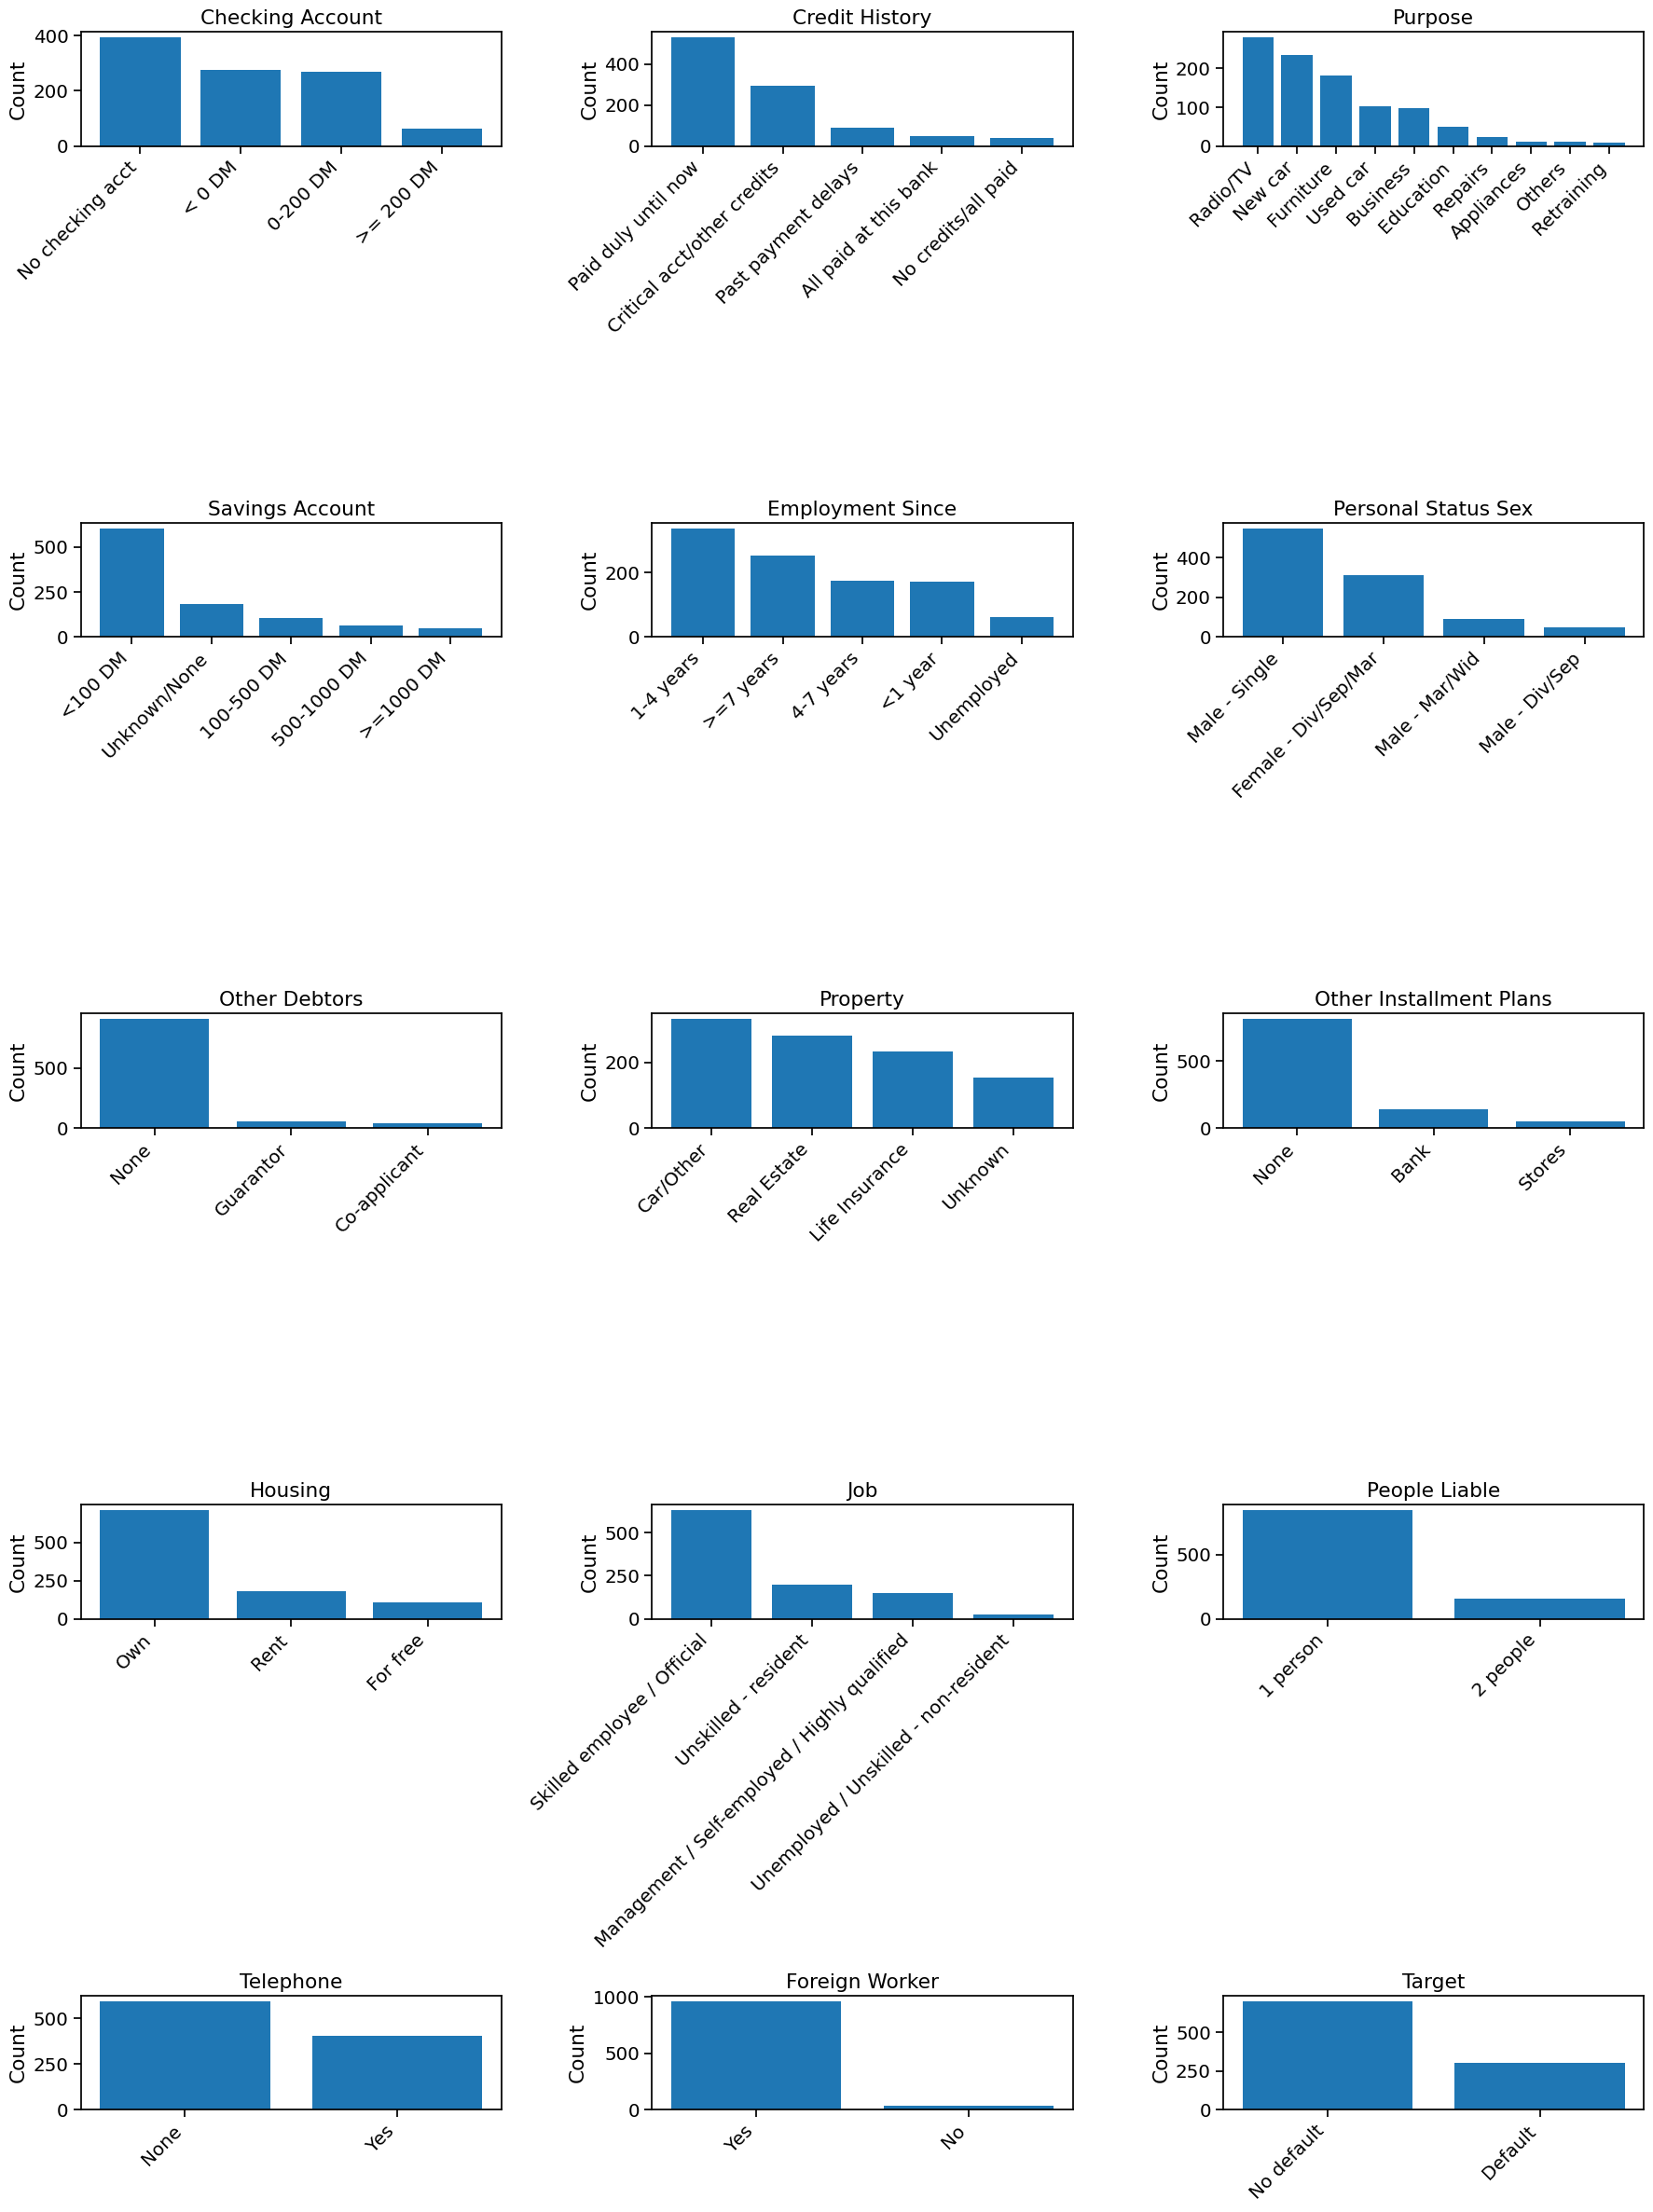

In [0]:
fig, axes = plt.subplots(5, 3, figsize=(18, 24))
axes = axes.flatten()

for i, col in enumerate(cat_columns):

    counts = german_credit_df[col].value_counts()

    # Convert codes to readable labels
    labels = [
        label_maps[col].get(code, code)
        for code in counts.index
    ]

    axes[i].bar(range(len(counts)), counts.values)

    axes[i].set_xticks(range(len(counts)))
    axes[i].set_xticklabels(
        labels,
        rotation=45,
        ha='right'
    )

    axes[i].set_title(f'{col.replace("_", " ").title()}')
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [0]:
eda_cat_columns = ["credit_history", "purpose", "employment_since", "job"]

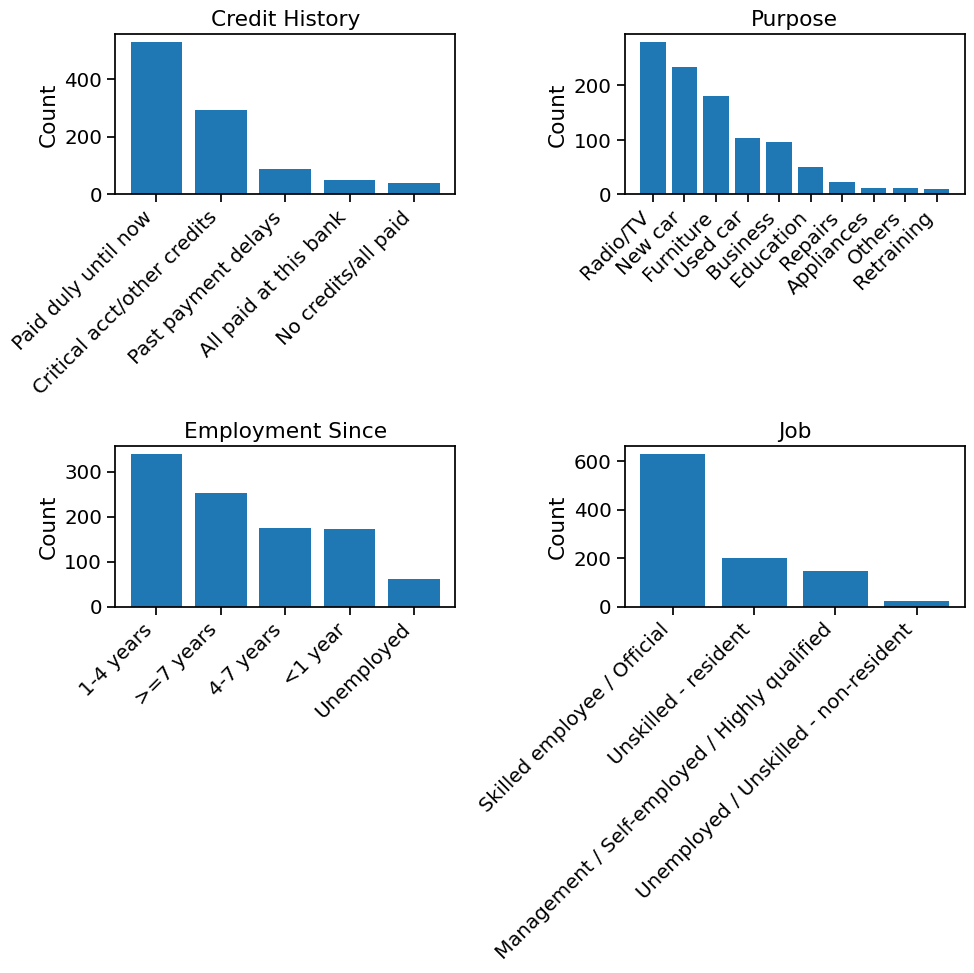

In [0]:
fig, axes = plt.subplots(2,2, figsize=(10, 10))
axes = axes.flatten()

for i, col in enumerate(eda_cat_columns):

    counts = german_credit_df[col].value_counts()

    # Convert codes to readable labels
    labels = [
        label_maps[col].get(code, code)
        for code in counts.index
    ]

    axes[i].bar(range(len(counts)), counts.values)

    axes[i].set_xticks(range(len(counts)))
    axes[i].set_xticklabels(
        labels,
        rotation=45,
        ha='right'
    )

    axes[i].set_title(f'{col.replace("_", " ").title()}')
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.savefig('german_credit_cat_eda.png', dpi=300, bbox_inches='tight')
plt.show()

### Distribution of Numerical Variables

In [0]:
num_columns = ["duration_months", "credit_amount", "installment_rate", "present_residence_since", "age", "existing_credits"]

In [0]:
for col in num_columns:
    print(f"-------- {col.replace("_", " ").title()} --------")
    print(german_credit_df[col].describe())
    print("\n")

-------- Duration Months --------
count    1000.000000
mean       20.903000
std        12.058814
min         4.000000
25%        12.000000
50%        18.000000
75%        24.000000
max        72.000000
Name: duration_months, dtype: float64


-------- Credit Amount --------
count     1000.000000
mean      3271.258000
std       2822.736876
min        250.000000
25%       1365.500000
50%       2319.500000
75%       3972.250000
max      18424.000000
Name: credit_amount, dtype: float64


-------- Installment Rate --------
count    1000.000000
mean        2.973000
std         1.118715
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         4.000000
Name: installment_rate, dtype: float64


-------- Present Residence Since --------
count    1000.000000
mean        2.845000
std         1.103718
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         4.000000
Name: present_residence_since, dtype: float64


-------- A

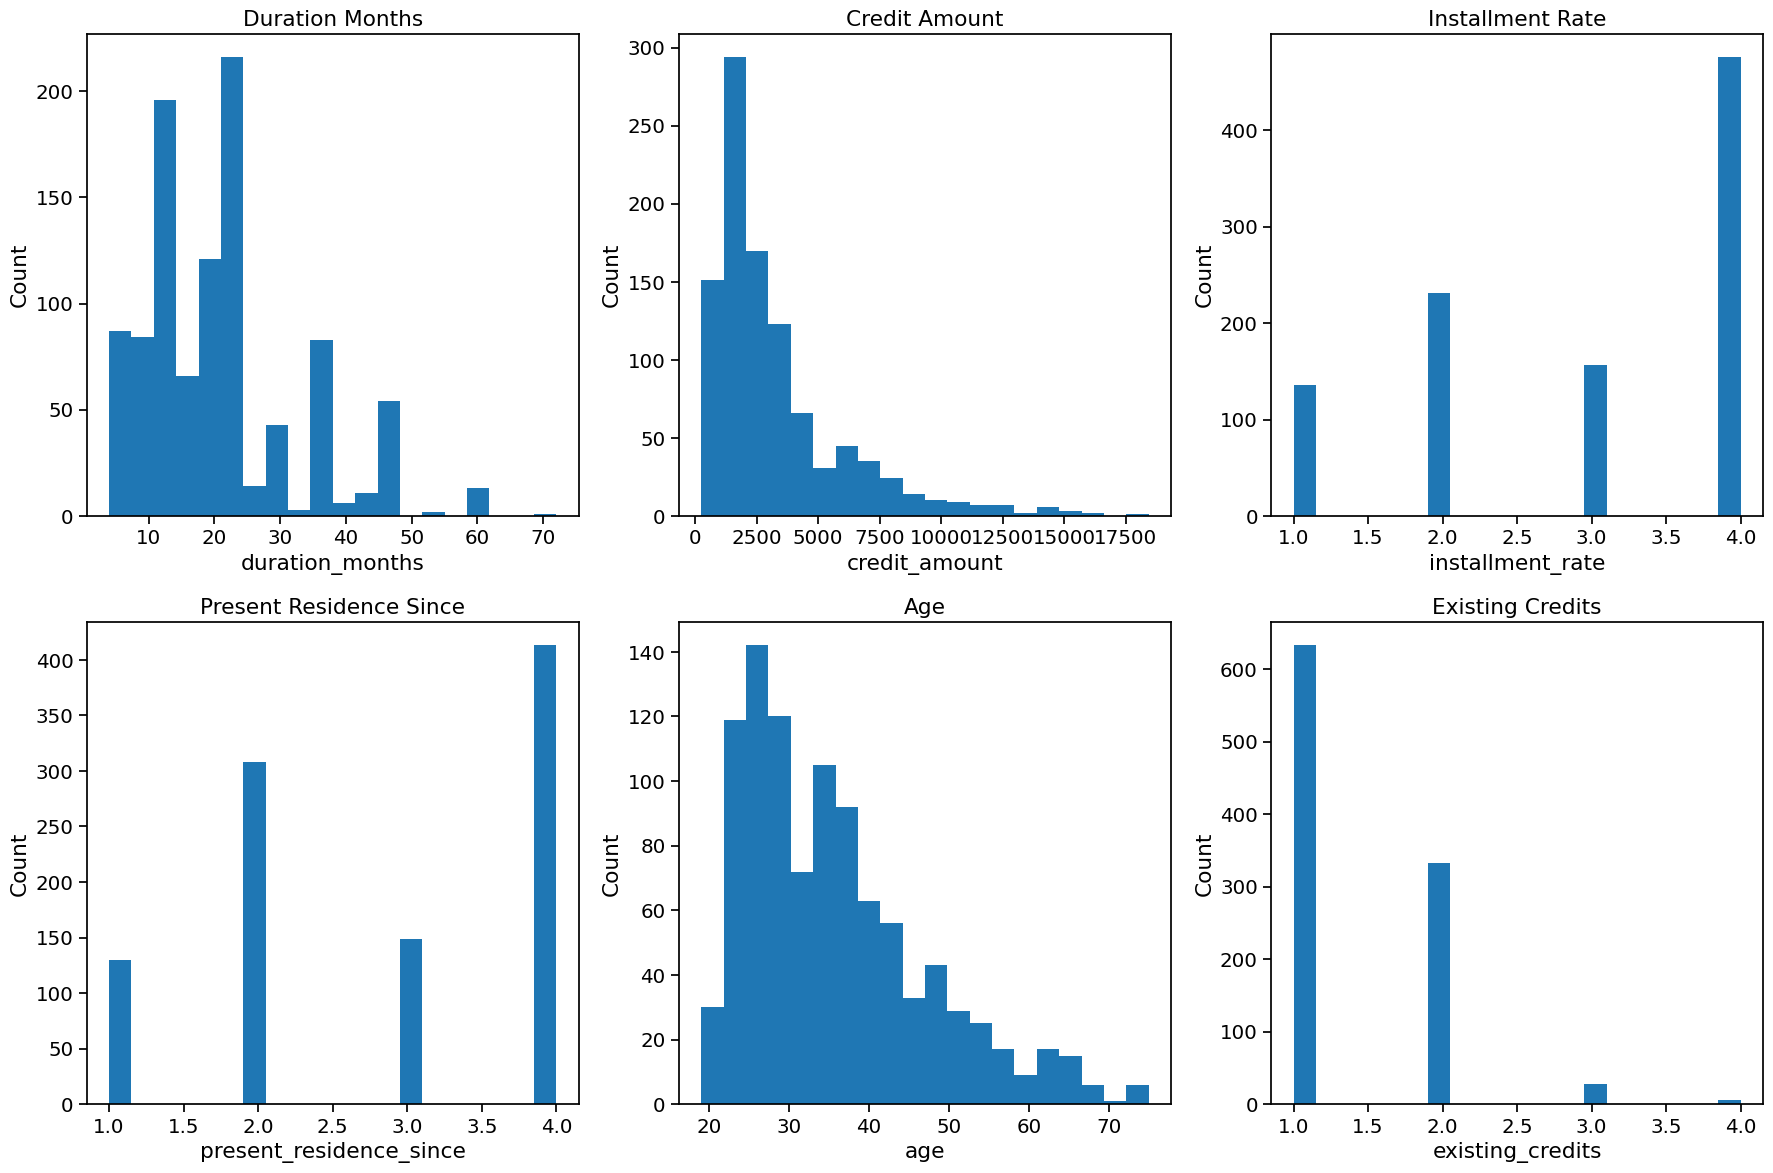

In [0]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(num_columns):
    axes[i].hist(german_credit_df[col], bins=20)
    axes[i].set_title(f'{col.replace("_", " ").title()}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')


plt.tight_layout()
plt.show()

In [0]:
eda_num_columns =  ["duration_months", "credit_amount", "age"]

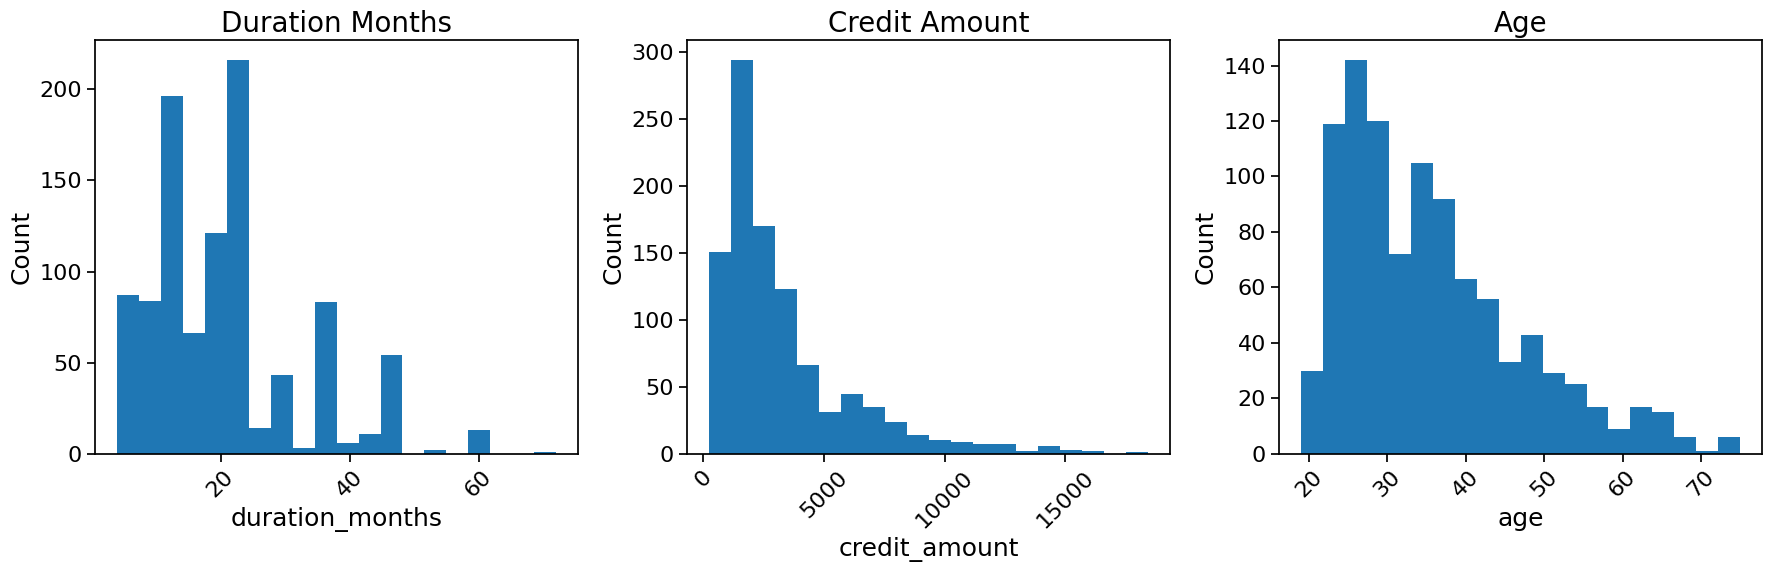

In [0]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes = axes.flatten()

for ax in axes.flat:
    ax.tick_params(axis='x', labelrotation=45)

for i, col in enumerate(eda_num_columns):
    axes[i].hist(german_credit_df[col], bins=20)
    axes[i].set_title(f'{col.replace("_", " ").title()}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')


plt.tight_layout()
plt.savefig('german_credit_num_eda.png', dpi=300, bbox_inches='tight')
plt.show()

## Modeling

In [0]:
num_features = num_columns

cat_columns.remove("target")
cat_features = cat_columns

features = num_features + cat_features

target = "target"

In [0]:
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

# 4. Replicating Cooper's Ensembling to study Self-Consistency

Measured Self-consistency (SC), Accuracy and Abstention rates of individual learning algorithms (Logistic Regression) with a threshold of 0.75

### Running Algorithm 1 - Simple Ensembling (With Logistic Regression)
Different models are produced by using different set of training points (by bootstrapping) and the models predict if the SC is high and abstain if the SC is low.

In [0]:
german_logistic_regression_results = run_n_splits_experiment(
    df=german_credit_df,
    features=features,
    target=target,
    num_features=num_features,
    cat_features=cat_features,
    model_type="Logistic Regression",
    B_ensembles=20,
    SC_threshold=0.75,
    n_splits=10
)

summary = pd.DataFrame({
    "Mean": german_logistic_regression_results.drop(columns=["split_seed"]).mean(numeric_only=True),
    "Std": german_logistic_regression_results.drop(columns=["split_seed"]).std(numeric_only=True)
})

print(summary)


---------------- LOGISTIC REGRESSION RESULTS ----------------

Average over 10 train-test splits:

abstention_rate                 0.268500
predicted_rate                  0.731500
mean_self_consistency           0.866682
ambiguity                       0.421500
non_abstain_accuracy            0.826135
non_abstain_precision           0.709146
non_abstain_recall              0.479528
non_abstain_f1                  0.569827
full_accuracy_no_abstention     0.762000
full_precision_no_abstention    0.621313
full_recall_no_abstention       0.507837
full_f1_no_abstention           0.557323
dtype: float64

Standard deviation over 10 train-test splits:

abstention_rate                 0.039655
predicted_rate                  0.039655
mean_self_consistency           0.017060
ambiguity                       0.048651
non_abstain_accuracy            0.039701
non_abstain_precision           0.112790
non_abstain_recall              0.067537
non_abstain_f1                  0.075812
full_accuracy_no_

### Running  Algorithm 2 - Super Ensembling (With Random Forest)
Here, we used bagged models. When these bagged models are trained on bootstrapped data, the bagging process in these models reduce the variance and we expect the ensemble of such bagged models to have higher SC and lower abstention rates.

In [0]:
german_random_forest_results = run_n_splits_experiment(
    df=german_credit_df,
    features=features,
    target=target,
    num_features=num_features,
    cat_features=cat_features,
    model_type="Random Forest",
    B_ensembles=20,
    SC_threshold=0.75,
    n_splits=10
)

summary = pd.DataFrame({
    "Mean": german_random_forest_results.drop(columns=["split_seed"]).mean(numeric_only=True),
    "Std": german_random_forest_results.drop(columns=["split_seed"]).std(numeric_only=True)
})

print(summary)


================ RANDOM FOREST RESULTS ================

Average over 10 train-test splits:

abstention_rate                 0.240000
predicted_rate                  0.760000
mean_self_consistency           0.881803
ambiguity                       0.378000
non_abstain_accuracy            0.808189
non_abstain_precision           0.764643
non_abstain_recall              0.177800
non_abstain_f1                  0.284776
full_accuracy_no_abstention     0.753500
full_precision_no_abstention    0.685842
full_recall_no_abstention       0.305514
full_f1_no_abstention           0.421340
dtype: float64

Standard deviation over 10 train-test splits:

abstention_rate                 0.027889
predicted_rate                  0.027889
mean_self_consistency           0.014239
ambiguity                       0.039665
non_abstain_accuracy            0.027771
non_abstain_precision           0.095169
non_abstain_recall              0.057581
non_abstain_f1                  0.073281
full_accuracy_no_absten

### Running Decision Tree

In [0]:
german_decision_tree_results = run_n_splits_experiment(
    df=german_credit_df,
    features=features,
    target=target,
    num_features=num_features,
    cat_features=cat_features,
    model_type="Decision Tree",
    B_ensembles=20,
    SC_threshold=0.75,
    n_splits=10
)

summary = pd.DataFrame({
    "Mean": german_decision_tree_results.drop(columns=["split_seed"]).mean(numeric_only=True),
    "Std": german_decision_tree_results.drop(columns=["split_seed"]).std(numeric_only=True)
})

print(summary)


================ DECISION TREE RESULTS ================

Average over 10 train-test splits:

abstention_rate                 0.684000
predicted_rate                  0.316000
mean_self_consistency           0.677945
ambiguity                       0.840500
non_abstain_accuracy            0.897346
non_abstain_precision           0.808333
non_abstain_recall              0.262110
non_abstain_f1                  0.377324
full_accuracy_no_abstention     0.737000
full_precision_no_abstention    0.572474
full_recall_no_abstention       0.430178
full_f1_no_abstention           0.488469
dtype: float64

Standard deviation over 10 train-test splits:

abstention_rate                 0.040607
predicted_rate                  0.040607
mean_self_consistency           0.016647
ambiguity                       0.034274
non_abstain_accuracy            0.028648
non_abstain_precision           0.242320
non_abstain_recall              0.146904
non_abstain_f1                  0.158064
full_accuracy_no_absten

## Studying Accuracy vs Self-Consistency

Plotted Accuracy vs SC, Accuracy vs Ambiguity and SC Ambiguity using the above ensembling technique for different train test splits using different Learning Algorithms  (Logistic Regression, Decision Tree, Random Forest, Gradient Boosting)

- 100 train-test splits to produce ensembles
- Each ensemble consisting of 20 models trained by bootstrapping training data

### Using Logistic Regression (100 train-test splits with ensemble size 20)

In [0]:
german_logistic_regression_20split_results = run_n_splits_experiment(
    df=german_credit_df,
    features=features,
    target=target,
    num_features=num_features,
    cat_features=cat_features,
    model_type="Logistic Regression",
    B_ensembles=20,
    SC_threshold=0.75,
    n_splits=100
)

summary = pd.DataFrame({
    "Mean": german_logistic_regression_20split_results.drop(columns=["split_seed"]).mean(numeric_only=True),
    "Std": german_logistic_regression_20split_results.drop(columns=["split_seed"]).std(numeric_only=True)
})

print(summary)


---------------- LOGISTIC REGRESSION RESULTS ----------------

Average over 100 train-test splits:

abstention_rate                 0.272900
predicted_rate                  0.727100
mean_self_consistency           0.866257
ambiguity                       0.422000
non_abstain_accuracy            0.823526
non_abstain_precision           0.703657
non_abstain_recall              0.451453
non_abstain_f1                  0.545065
full_accuracy_no_abstention     0.753750
full_precision_no_abstention    0.618753
full_recall_no_abstention       0.474254
full_f1_no_abstention           0.534071
dtype: float64

Standard deviation over 100 train-test splits:

abstention_rate                 0.033388
predicted_rate                  0.033388
mean_self_consistency           0.014344
ambiguity                       0.040720
non_abstain_accuracy            0.029798
non_abstain_precision           0.103826
non_abstain_recall              0.084100
non_abstain_f1                  0.080717
full_accuracy_n

### Using Random Forest (100 train-test splits with ensemble size 20)

In [0]:
german_random_forest_20split_results = run_n_splits_experiment(
    df=german_credit_df,
    features=features,
    target=target,
    num_features=num_features,
    cat_features=cat_features,
    model_type="Random Forest",
    B_ensembles=20,
    SC_threshold=0.75,
    n_splits=100
)

summary = pd.DataFrame({
    "Mean": german_random_forest_20split_results.drop(columns=["split_seed"]).mean(numeric_only=True),
    "Std": german_random_forest_20split_results.drop(columns=["split_seed"]).std(numeric_only=True)
})

print(summary)


---------------- RANDOM FOREST RESULTS ----------------

Average over 100 train-test splits:

abstention_rate                 0.242300
predicted_rate                  0.757700
mean_self_consistency           0.881051
ambiguity                       0.379400
non_abstain_accuracy            0.802213
non_abstain_precision           0.805938
non_abstain_recall              0.178255
non_abstain_f1                  0.286521
full_accuracy_no_abstention     0.749650
full_precision_no_abstention    0.698812
full_recall_no_abstention       0.298153
full_f1_no_abstention           0.414843
dtype: float64

Standard deviation over 100 train-test splits:

abstention_rate                 0.032586
predicted_rate                  0.032586
mean_self_consistency           0.013508
ambiguity                       0.035578
non_abstain_accuracy            0.032323
non_abstain_precision           0.140547
non_abstain_recall              0.061212
non_abstain_f1                  0.082904
full_accuracy_no_abst

### Using Decision Tree (100 train-test splits with ensemble size 20)

In [0]:
german_decision_tree_20split_results = run_n_splits_experiment(
    df=german_credit_df,
    features=features,
    target=target,
    num_features=num_features,
    cat_features=cat_features,
    model_type="Decision Tree",
    B_ensembles=20,
    SC_threshold=0.75,
    n_splits=100
)

summary = pd.DataFrame({
    "Mean": german_decision_tree_20split_results.drop(columns=["split_seed"]).mean(numeric_only=True),
    "Std": german_decision_tree_20split_results.drop(columns=["split_seed"]).std(numeric_only=True)
})

print(summary)


---------------- DECISION TREE RESULTS ----------------

Average over 100 train-test splits:

abstention_rate                 0.679050
predicted_rate                  0.320950
mean_self_consistency           0.679251
ambiguity                       0.842800
non_abstain_accuracy            0.901586
non_abstain_precision           0.756667
non_abstain_recall              0.264672
non_abstain_f1                  0.373591
full_accuracy_no_abstention     0.730300
full_precision_no_abstention    0.571123
full_recall_no_abstention       0.413747
full_f1_no_abstention           0.476889
dtype: float64

Standard deviation over 100 train-test splits:

abstention_rate                 0.034936
predicted_rate                  0.034936
mean_self_consistency           0.013354
ambiguity                       0.028739
non_abstain_accuracy            0.034221
non_abstain_precision           0.348139
non_abstain_recall              0.174322
non_abstain_f1                  0.204307
full_accuracy_no_abst

### Using Gradient Boosting (100 train-test splits with ensemble size 20)

In [0]:
german_gb_20split_results = run_n_splits_experiment(
    df=german_credit_df,
    features=features,
    target=target,
    num_features=num_features,
    cat_features=cat_features,
    model_type="Gradient Boosting",
    B_ensembles=20,
    SC_threshold=0.75,
    n_splits=100
)

summary = pd.DataFrame({
    "Mean": german_gb_20split_results.drop(columns=["split_seed"]).mean(numeric_only=True),
    "Std": german_gb_20split_results.drop(columns=["split_seed"]).std(numeric_only=True)
})

print(summary)


---------------- GRADIENT BOOSTING RESULTS ----------------

Average over 100 train-test splits:

abstention_rate                 0.330350
predicted_rate                  0.669650
mean_self_consistency           0.837960
ambiguity                       0.516500
non_abstain_accuracy            0.836083
non_abstain_precision           0.749028
non_abstain_recall              0.337680
non_abstain_f1                  0.459184
full_accuracy_no_abstention     0.752000
full_precision_no_abstention    0.641237
full_recall_no_abstention       0.399929
full_f1_no_abstention           0.489667
dtype: float64

Standard deviation over 100 train-test splits:

abstention_rate                 0.034114
predicted_rate                  0.034114
mean_self_consistency           0.013880
ambiguity                       0.033216
non_abstain_accuracy            0.028841
non_abstain_precision           0.102216
non_abstain_recall              0.077329
non_abstain_f1                  0.078148
full_accuracy_no_

### Plotting Accuracy vs SC for all model types

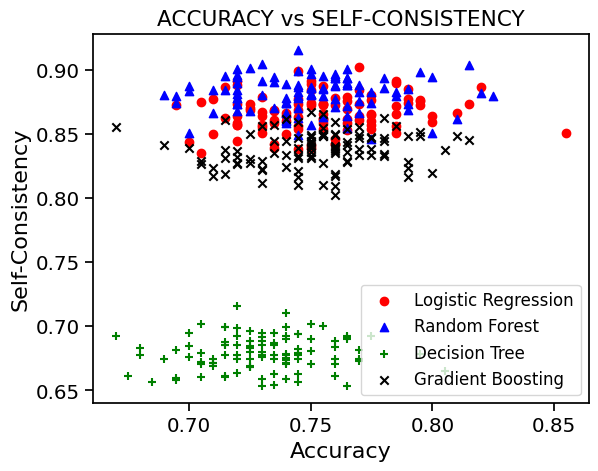

In [0]:
plt.scatter(german_logistic_regression_20split_results['full_accuracy_no_abstention'], german_logistic_regression_20split_results['mean_self_consistency'], color = "red", label = "Logistic Regression", marker = "o")
plt.scatter(german_random_forest_20split_results['full_accuracy_no_abstention'], german_random_forest_20split_results['mean_self_consistency'], color = "blue", label = "Random Forest", marker = "^")
plt.scatter(german_decision_tree_20split_results['full_accuracy_no_abstention'], german_decision_tree_20split_results['mean_self_consistency'], color = "green", label = "Decision Tree", marker = "+")
plt.scatter(german_gb_20split_results['full_accuracy_no_abstention'], german_gb_20split_results['mean_self_consistency'], color = "black", label = "Gradient Boosting", marker = "x")
plt.xlabel("Accuracy", fontsize = 16)
plt.ylabel("Self-Consistency", fontsize = 16)
plt.title("ACCURACY vs SELF-CONSISTENCY")

plt.legend(fontsize = 12, loc = 'lower right')
plt.savefig("acc_sc_german.png", dpi=300, bbox_inches="tight")
plt.show()

### Plotting Accuracy vs Ambiguity for all model types

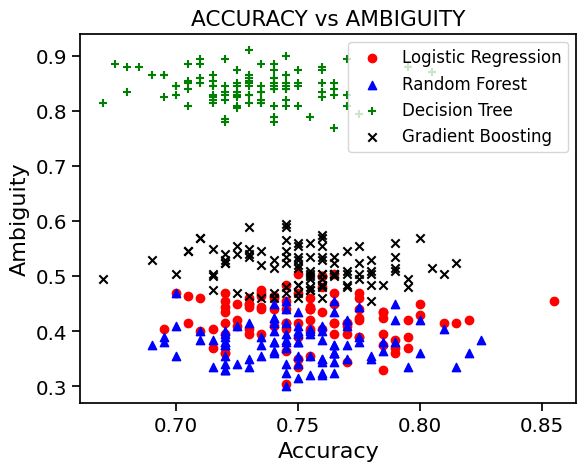

In [0]:
plt.scatter(german_logistic_regression_20split_results['full_accuracy_no_abstention'], german_logistic_regression_20split_results['ambiguity'], color = "red", label = "Logistic Regression", marker = "o")
plt.scatter(german_random_forest_20split_results['full_accuracy_no_abstention'], german_random_forest_20split_results['ambiguity'], color = "blue", label = "Random Forest", marker = "^")
plt.scatter(german_decision_tree_20split_results['full_accuracy_no_abstention'], german_decision_tree_20split_results['ambiguity'], color = "green", label = "Decision Tree", marker = "+")
plt.scatter(german_gb_20split_results['full_accuracy_no_abstention'], german_gb_20split_results['ambiguity'], color = "black", label = "Gradient Boosting", marker = "x")
plt.xlabel("Accuracy", fontsize = 16)
plt.ylabel("Ambiguity", fontsize = 16)
plt.title("ACCURACY vs AMBIGUITY")

plt.legend(fontsize = 12, loc = 'upper right')
plt.savefig("acc_amb_german.png", dpi=300, bbox_inches="tight")
plt.show()

### Plotting Self-Consistency vs Ambiguity for all model types

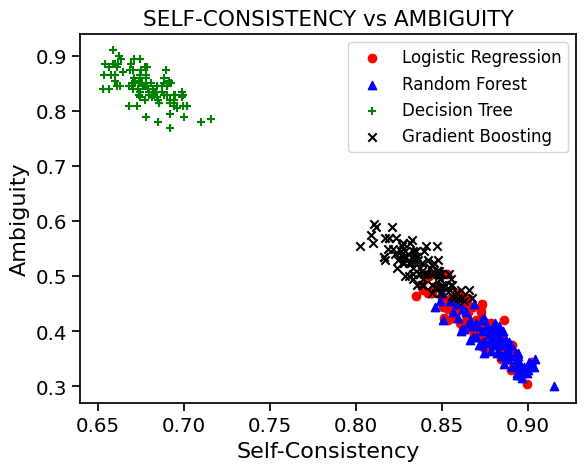

In [0]:
plt.scatter(german_logistic_regression_20split_results['mean_self_consistency'], german_logistic_regression_20split_results['ambiguity'], color = "red", label = "Logistic Regression", marker = "o")
plt.scatter(german_random_forest_20split_results['mean_self_consistency'], german_random_forest_20split_results['ambiguity'], color = "blue", label = "Random Forest", marker = "^")
plt.scatter(german_decision_tree_20split_results['mean_self_consistency'], german_decision_tree_20split_results['ambiguity'], color = "green", label = "Decision Tree", marker = "+")
plt.scatter(german_gb_20split_results['mean_self_consistency'], german_gb_20split_results['ambiguity'], color = "black", label = "Gradient Boosting", marker = "x")
plt.xlabel("Self-Consistency", fontsize = 16)
plt.ylabel("Ambiguity", fontsize = 16)
plt.title("SELF-CONSISTENCY vs AMBIGUITY")

plt.legend(fontsize = 12, loc = 'upper right')
plt.savefig("sc_amb_german.png", dpi=300, bbox_inches="tight")
plt.show()

# 5. Selective Ensembling

Constructed ensembles of individual learners (Logistic Regression, Decision Tree, Random Forest, Gradient Boosting) by bootstrapping and used majority vote for final prediction.  

Measured Self-consistency (SC), Accuracy and Abstention rates of these ensembles with a threshold of 0.75

%md
- Number of Ensembles (E) = 10
- Number of models in each Ensemble (B) = 11

In [0]:
models_set = ["Logistic Regression", "Random Forest", "Decision Tree", "Gradient Boosting"]

for model in models_set:
    ensemble_agreement(
        df=german_credit_df,
        features=features,
        target=target,
        num_features=num_features,
        cat_features=cat_features,
        model_type=model,
        ensemble_size=11,
        SC_threshold=0.75,
        n_ensembles=10
    )


---------------- LOGISTIC REGRESSION RESULTS ----------------

model_type                      Logistic Regression
abstention_rate                                0.07
predicted_rate                                 0.93
mean_self_consistency                      0.964889
ambiguity                                     0.355
non_abstain_accuracy                        0.77957
non_abstain_precision                      0.666667
non_abstain_recall                         0.423077
non_abstain_f1                             0.517647
full_accuracy_no_abstention                   0.765
full_precision_no_abstention               0.642857
full_recall_no_abstention                  0.457627
full_f1_no_abstention                      0.534653
Name: 0, dtype: object

---------------- RANDOM FOREST RESULTS ----------------

model_type                      Random Forest
abstention_rate                          0.08
predicted_rate                           0.92
mean_self_consistency                0.95

%md
Running the Selective Ensembling experiment across 10 different train-test splits

In [0]:
models_set = ["Logistic Regression", "Random Forest", "Decision Tree", "Gradient Boosting"]

for model in models_set:
    print(f"\n---------------- {model.upper()} RESULTS ----------------\n")
    selective_ensembling_split_results = ensemble_agreement_n_splits(
            df=german_credit_df,
            features=features,
            target=target,
            num_features=num_features,
            cat_features=cat_features,
            model_type=model,
            ensemble_size=11,
            SC_threshold=0.75,
            n_ensembles=10,
            splits = 10
        )
    
    summary = pd.DataFrame({
        "Mean": selective_ensembling_split_results.mean(numeric_only=True),
        "Std": selective_ensembling_split_results.std(numeric_only=True)
    })

    print(summary)


---------------- LOGISTIC REGRESSION RESULTS ----------------

                                  Mean       Std
abstention_rate               0.054500  0.014230
predicted_rate                0.945500  0.014230
mean_self_consistency         0.971478  0.006330
ambiguity                     0.366500  0.057641
non_abstain_accuracy          0.775312  0.042388
non_abstain_precision         0.632299  0.083617
non_abstain_recall            0.523278  0.069703
non_abstain_f1                0.570746  0.069113
full_accuracy_no_abstention   0.768500  0.040692
full_precision_no_abstention  0.629049  0.071961
full_recall_no_abstention     0.536275  0.061280
full_f1_no_abstention         0.577348  0.058397

---------------- RANDOM FOREST RESULTS ----------------

                                  Mean       Std
abstention_rate               0.066000  0.014298
predicted_rate                0.934000  0.014298
mean_self_consistency         0.963011  0.009312
ambiguity                     0.329500  0.043

### Visualization for comparing Cooper's Ensembling with Selective Ensembling

In [0]:
cooper_df = run_n_splits_experiment(
    df=german_credit_df, features=features, target=target,
    num_features=num_features, cat_features=cat_features,
    model_type="Logistic Regression",  # match whichever model_type you've been using
    B_ensembles=11, SC_threshold=0.75, n_splits=10
)
cooper_df["split"] = range(1, 11)
cooper_df["method"] = "Cooper's Ensemble"

selective_df = ensemble_agreement_n_splits(
    df=german_credit_df, features=features, target=target,
    num_features=num_features, cat_features=cat_features,
    model_type="Logistic Regression",
    ensemble_size=11, SC_threshold=0.75, n_ensembles=10, splits=10
)
selective_df["split"] = range(1, 11)
selective_df["method"] = "Selective Ensembling"

combined_comparison_df = pd.concat([cooper_df, selective_df], ignore_index=True)


---------------- LOGISTIC REGRESSION RESULTS ----------------

Average over 10 train-test splits:

abstention_rate                 0.253500
predicted_rate                  0.746500
mean_self_consistency           0.865364
ambiguity                       0.372000
non_abstain_accuracy            0.817138
non_abstain_precision           0.693130
non_abstain_recall              0.468687
non_abstain_f1                  0.556696
full_accuracy_no_abstention     0.762000
full_precision_no_abstention    0.616079
full_recall_no_abstention       0.519965
full_f1_no_abstention           0.561912
dtype: float64

Standard deviation over 10 train-test splits:

abstention_rate                 0.039303
predicted_rate                  0.039303
mean_self_consistency           0.018044
ambiguity                       0.046080
non_abstain_accuracy            0.044519
non_abstain_precision           0.110442
non_abstain_recall              0.062284
non_abstain_f1                  0.070538
full_accuracy_no_

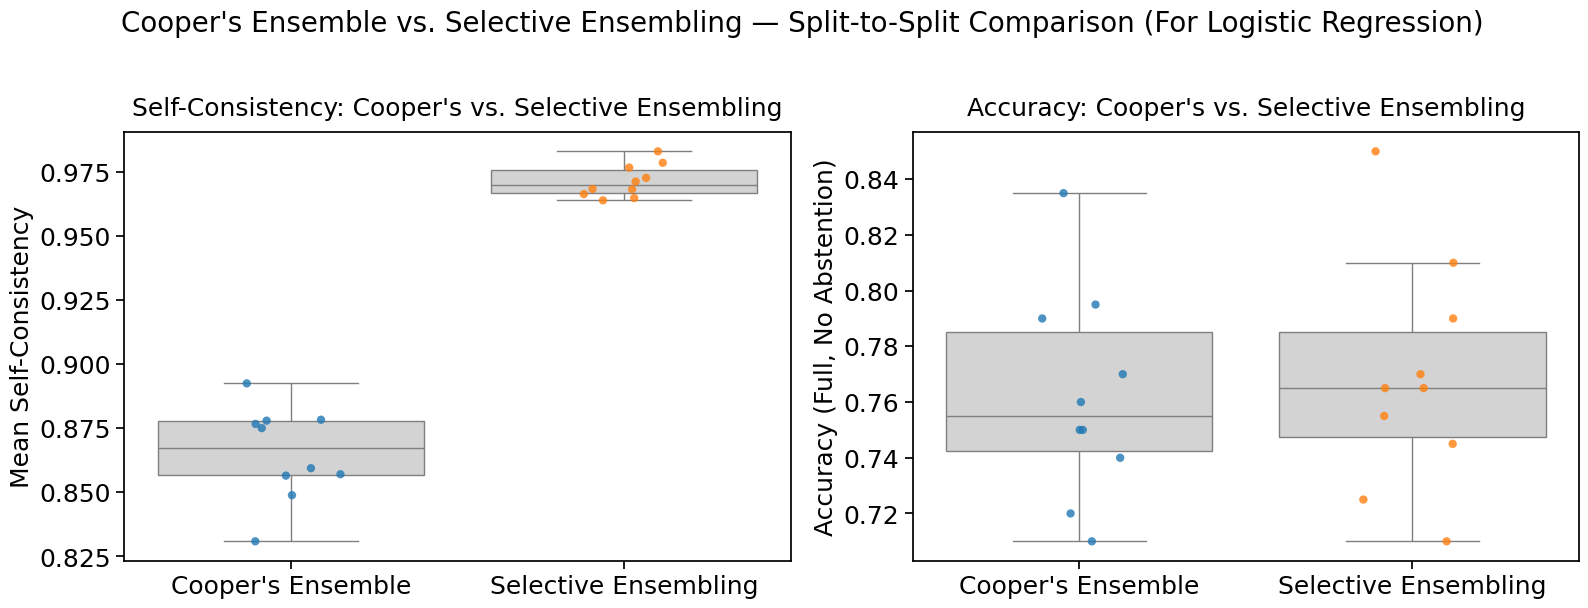

In [0]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Self-consistency ---
sns.boxplot(
    data=combined_comparison_df,
    x="method",
    y="mean_self_consistency",
    ax=axes[0],
    color="lightgray",
    fliersize=0
)
sns.stripplot(
    data=combined_comparison_df,
    x="method",
    y="mean_self_consistency",
    ax=axes[0],
    hue="method",
    size=6,
    jitter=0.15,
    alpha=0.8,
    legend=False
)

axes[0].set_xlabel("", fontsize=18)
axes[0].set_ylabel("Mean Self-Consistency", fontsize=18)
axes[0].set_title(
    "Self-Consistency: Cooper's vs. Selective Ensembling",
    fontsize=18,
    pad=12
)
axes[0].tick_params(axis="both", labelsize=18)


# --- Accuracy ---
sns.boxplot(
    data=combined_comparison_df,
    x="method",
    y="full_accuracy_no_abstention",
    ax=axes[1],
    color="lightgray",
    fliersize=0
)
sns.stripplot(
    data=combined_comparison_df,
    x="method",
    y="full_accuracy_no_abstention",
    ax=axes[1],
    hue="method",
    size=6,
    jitter=0.15,
    alpha=0.8,
    legend=False
)

axes[1].set_xlabel("", fontsize=18)
axes[1].set_ylabel("Accuracy (Full, No Abstention)", fontsize=18)
axes[1].set_title(
    "Accuracy: Cooper's vs. Selective Ensembling",
    fontsize=18,
    pad=12
)
axes[1].tick_params(axis="both", labelsize=18)


# Overall title
fig.suptitle(
    "Cooper's Ensemble vs. Selective Ensembling — Split-to-Split Comparison (For Logistic Regression)",
    fontsize=20,
    y=1.02
)

fig.tight_layout()

fig.savefig(
    "german_credit_simple_vs_selective_ensemble.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [0]:
cooper_df_rf = run_n_splits_experiment(
    df=german_credit_df, features=features, target=target,
    num_features=num_features, cat_features=cat_features,
    model_type="Random Forest",
    B_ensembles=11, SC_threshold=0.75, n_splits=10
)
cooper_df_rf["split"] = range(1, 11)
cooper_df_rf["method"] = "Cooper's Ensemble"

selective_df_rf = ensemble_agreement_n_splits(
    df=german_credit_df, features=features, target=target,
    num_features=num_features, cat_features=cat_features,
    model_type="Random Forest",
    ensemble_size=11, SC_threshold=0.75, n_ensembles=10, splits=10
)
selective_df_rf["split"] = range(1, 11)
selective_df_rf["method"] = "Selective Ensembling"

combined_comparison_df_rf = pd.concat([cooper_df_rf, selective_df_rf], ignore_index=True)


---------------- RANDOM FOREST RESULTS ----------------

Average over 10 train-test splits:

abstention_rate                 0.223000
predicted_rate                  0.777000
mean_self_consistency           0.884200
ambiguity                       0.320500
non_abstain_accuracy            0.808394
non_abstain_precision           0.770409
non_abstain_recall              0.213101
non_abstain_f1                  0.328971
full_accuracy_no_abstention     0.752500
full_precision_no_abstention    0.673994
full_recall_no_abstention       0.318123
full_f1_no_abstention           0.430765
dtype: float64

Standard deviation over 10 train-test splits:

abstention_rate                 0.030111
predicted_rate                  0.030111
mean_self_consistency           0.013684
ambiguity                       0.029482
non_abstain_accuracy            0.022956
non_abstain_precision           0.069670
non_abstain_recall              0.066757
non_abstain_f1                  0.080753
full_accuracy_no_absten

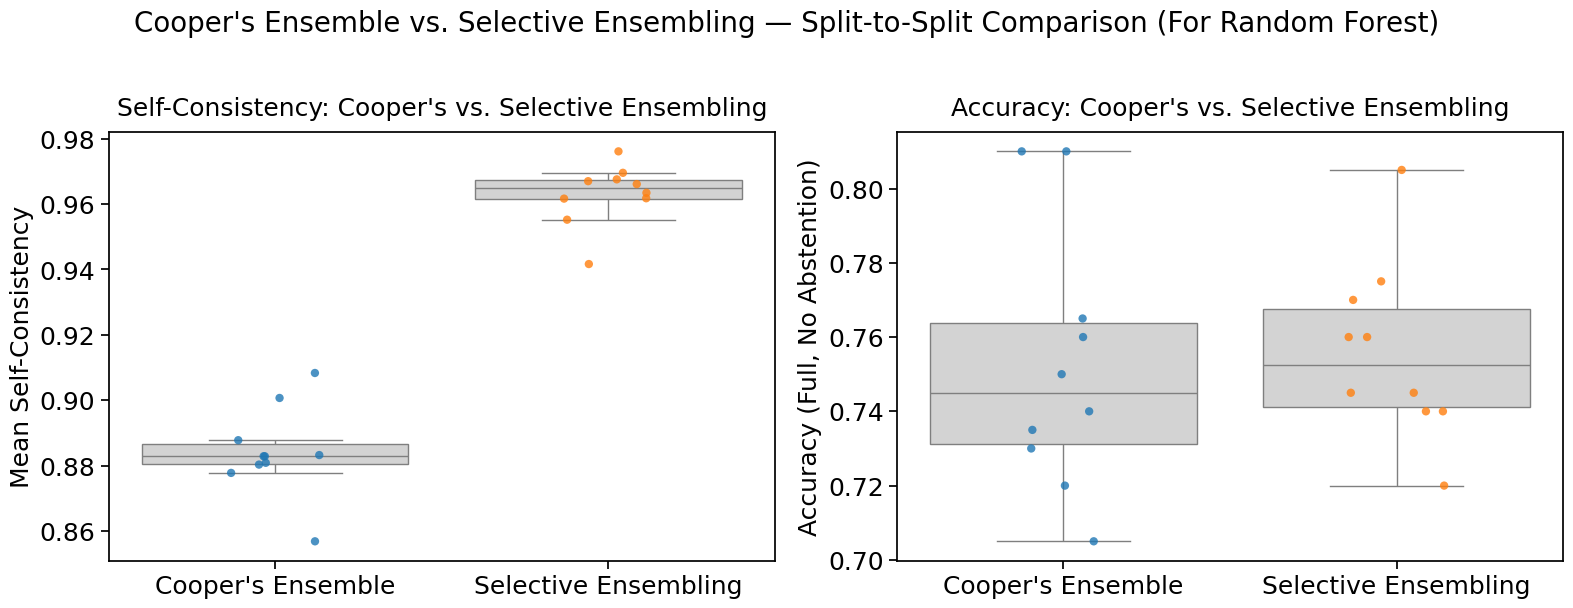

In [0]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Self-consistency ---
sns.boxplot(
    data=combined_comparison_df_rf,
    x="method",
    y="mean_self_consistency",
    ax=axes[0],
    color="lightgray",
    fliersize=0
)
sns.stripplot(
    data=combined_comparison_df_rf,
    x="method",
    y="mean_self_consistency",
    ax=axes[0],
    hue="method",
    size=6,
    jitter=0.15,
    alpha=0.8,
    legend=False
)

axes[0].set_xlabel("", fontsize=18)
axes[0].set_ylabel("Mean Self-Consistency", fontsize=18)
axes[0].set_title(
    "Self-Consistency: Cooper's vs. Selective Ensembling",
    fontsize=18,
    pad=12
)
axes[0].tick_params(axis="both", labelsize=18)


# --- Accuracy ---
sns.boxplot(
    data=combined_comparison_df_rf,
    x="method",
    y="full_accuracy_no_abstention",
    ax=axes[1],
    color="lightgray",
    fliersize=0
)
sns.stripplot(
    data=combined_comparison_df_rf,
    x="method",
    y="full_accuracy_no_abstention",
    ax=axes[1],
    hue="method",
    size=6,
    jitter=0.15,
    alpha=0.8,
    legend=False
)

axes[1].set_xlabel("", fontsize=18)
axes[1].set_ylabel("Accuracy (Full, No Abstention)", fontsize=18)
axes[1].set_title(
    "Accuracy: Cooper's vs. Selective Ensembling",
    fontsize=18,
    pad=12
)
axes[1].tick_params(axis="both", labelsize=18)


# Overall title
fig.suptitle(
    "Cooper's Ensemble vs. Selective Ensembling — Split-to-Split Comparison (For Random Forest)",
    fontsize=20,
    y=1.02
)

fig.tight_layout()

fig.savefig(
    "german_credit_simple_vs_selective_ensemble_random_forest.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 6. Super Learner Ensembling

Constructed Super Learner using 4 different learning algorithms (Logistic Regression, Decision Tree, Random Forest, Gradient Boosting) and used Logistic Regression as the Meta Learner which combines predictions of individual learners to give final predictions.  

Measured the SC and Accuracy of Super Learner and the individual learners by bootstrapping the training data to obtain different training sets

- 20 Super Learners are constructed by bootstrapping the training data
- 10-fold CV is used to construct the Super Learner

In [0]:
def weighted_log_loss_objective(weights, Z_stack, y_val):
    weights = softmax(weights)
    combined = Z_stack @ weights
    # Clipping values to tackle infinity cases in log loss function
    combined = np.clip(combined, 1e-7, 1 - 1e-7)
    return log_loss(y_val, combined)

In [0]:
class WeightedLogLossSuperLearner:
    def __init__(self, models_count, optimizer = "Powell", threshold = 0.5):
        self.models_count = models_count
        self.final_weights = np.empty(self.models_count)
        self.threshold = threshold
        self.optimizer = optimizer
        self.optimizer_result = False

    def fit(self, Z_stack, y):
        if Z_stack.shape[1] != self.models_count:
            raise Exception("Model Count does not match the columns in Base Learner Predictions")

        x0 = np.zeros(self.models_count)  

        result = minimize(
            weighted_log_loss_objective,
            x0 = x0,
            args = (Z_stack, y),
            method = self.optimizer
        )

        self.final_weights = softmax(result.x)
        self.optimizer_result = result.success
        return self

    def predict_proba(self, Z_stack):
        return Z_stack @ self.final_weights

    def predict(self, Z_stack):
        pred_probs = Z_stack @ self.final_weights
        return np.where(pred_probs >= self.threshold, 1, 0)

In [0]:
def ClassicalSuperLearnerEnsembleAgreement(df, features, target, num_features, cat_features, model_types, n_splits = 10, cv_folds = 10, do_bootstrap = False, random_state = 1):
    results = []
    split_predictions = []
    M = len(model_types)
    base_predictions = {model_type: [] for model_type in model_types}

    X_train, X_test, y_train, y_test = train_test_split(
                df[features],
                df[target],
                test_size = 0.2,
                random_state = random_state
            )
    
    X_train_processed, X_test_processed = preprocess_split(
            X_train,
            X_test,
            num_features,
            cat_features
        )

    for split_seed in range(1, n_splits+1):
        split_result = {}
        
        meta_Z, meta_y = list(), list()        

        X_train_split = X_train_processed.copy()
        y_train_split = y_train.copy()

        if do_bootstrap:
            X_train_split, y_train_split = resample(
                X_train_split,
                y_train_split,
                replace=True,
                random_state = split_seed
            )

        kfold = KFold(n_splits=cv_folds, random_state=split_seed, shuffle=True)

        for train_ix, test_ix in kfold.split(X_train_split):
            fold_yhats = list()
            train_X, test_X = X_train_split[train_ix], X_train_split[test_ix]
            train_y = y_train_split.iloc[train_ix]
            test_y = y_train_split.iloc[test_ix]
            meta_y.extend(test_y)
            for model_type in model_types:
                model = get_model(model_type = model_type, random_state = 1)
                model.fit(train_X, train_y)
                yhat = model.predict(test_X)
                fold_yhats.append(yhat)
            meta_Z.append(np.column_stack(fold_yhats))
    
        sl_Z = np.vstack(meta_Z)
        sl_y = np.asarray(meta_y)

        meta_model = WeightedLogLossSuperLearner(models_count = M)
        meta_model.fit(sl_Z, sl_y)
        
        base_models = list()
        for model_type in model_types:
            base_model = get_model(model_type = model_type, random_state = 1)
            base_model.fit(X_train_split, y_train_split)
            base_models.append(base_model)                       
            yhat = base_model.predict(X_test_processed)
            split_result[f"{model_type} accuracy"] = accuracy_score(y_test, yhat)
            base_predictions[model_type].append(yhat)

        meta_Z_test = list()
        for model in base_models:
            yhat = model.predict(X_test_processed)
            meta_Z_test.append(yhat)
        meta_Z_test = np.column_stack(meta_Z_test)
        yhat = meta_model.predict(meta_Z_test)
        split_result[f"Meta Model accuracy"] = accuracy_score(y_test, yhat)

        for i, model_type in enumerate(model_types):
            split_result[f"{model_type} (w)"] = meta_model.final_weights[i]
        
        split_predictions.append(yhat)
        results.append(split_result)
    
    split_predictions = np.array(split_predictions)
    sc_scores = []
    for i in range(X_test_processed.shape[0]):
        preds_for_point = split_predictions[:,i]
        sc = self_consistency(preds_for_point)
        sc_scores.append(sc)
    mean_sc = np.mean(sc_scores)

    results_df = pd.DataFrame(results)
    #display(results_df)
    #print(f"Mean Self Consistency (Pooled): {mean_sc}")
    results_df[f"Meta Learner SC"] = mean_sc

    if do_bootstrap:
        #print("------ Individual Learner Results (for Bootstrapped training data) ------")
        for model_type in model_types:
            predictions = np.asarray(base_predictions[model_type])
            sc_scores = []
            for i in range(X_test_processed.shape[0]):
                preds_for_point = predictions[:,i]
                sc = self_consistency(preds_for_point)
                #pred_results_for_point = aggregate_with_abstention(preds_for_point, SC_threshold)
                #sc = pred_results_for_point['self_consistency']
                sc_scores.append(sc)
            mean_sc = np.mean(sc_scores)
            #print(f"Mean Self Consistency ({model_type}): {mean_sc}")
            results_df[f"{model_type} SC"] = mean_sc

    return results_df

In [0]:
#Trial
models_set = ["Logistic Regression", "Random Forest", "Decision Tree", "Gradient Boosting"]

all_classical_results = []
for split in range(10):
    df_split = ClassicalSuperLearnerEnsembleAgreement(
        df=german_credit_df, features=features, target=target,
        num_features=num_features, cat_features=cat_features,
        model_types=models_set, n_splits=5, cv_folds=10,
        do_bootstrap=True, random_state=split+1
    )
    df_split["outer_split"] = split + 1
    all_classical_results.append(df_split)
combined_classical_df = pd.concat(all_classical_results, ignore_index=True)

In [0]:
combined_classical_df

,Logistic Regression accuracy,Random Forest accuracy,Decision Tree accuracy,Gradient Boosting accuracy,Meta Model accuracy,Logistic Regression (w),Random Forest (w),Decision Tree (w),Gradient Boosting (w),Meta Learner SC,Logistic Regression SC,Random Forest SC,Decision Tree SC,Gradient Boosting SC,outer_split
0,0.735,0.735,0.665,0.745,0.745,0.083865,0.494260,0.300146,0.121729,0.890,0.888,0.895,0.696,0.851,1
1,0.715,0.755,0.720,0.720,0.755,0.103822,0.574014,0.243968,0.078196,0.890,0.888,0.895,0.696,0.851,1
2,0.765,0.750,0.690,0.730,0.760,0.115344,0.475113,0.312410,0.097133,0.890,0.888,0.895,0.696,0.851,1
3,0.730,0.735,0.635,0.740,0.725,0.081202,0.424244,0.420214,0.074341,0.890,0.888,0.895,0.696,0.851,1
4,0.735,0.760,0.655,0.705,0.735,0.116000,0.496827,0.263890,0.123282,0.890,0.888,0.895,0.696,0.851,1
5,0.690,0.725,0.665,0.710,0.725,0.060722,0.525481,0.221680,0.192117,0.890,0.880,0.897,0.667,0.837,2
6,0.690,0.720,0.685,0.720,0.725,0.148002,0.415263,0.347069,0.089667,0.890,0.880,0.897,0.667,0.837,2
7,0.735,0.710,0.610,0.725,0.710,0.111340,0.410368,0.404491,0.073801,0.890,0.880,0.897,0.667,0.837,2
8,0.715,0.705,0.655,0.730,0.730,0.125880,0.482310,0.221438,0.170372,0.890,0.880,0.897,0.667,0.837,2
9,0.705,0.695,0.595,0.715,0.695,0.102137,0.553322,0.252849,0.091691,0.890,0.880,0.897,0.667,0.837,2


In [0]:
models_set = ["Logistic Regression", "Random Forest", "Decision Tree", "Gradient Boosting"]

ClassicalSuperLearnerEnsembleAgreement(df=german_credit_df,
    features=features,
    target=target,
    num_features=num_features,
    cat_features=cat_features,
    model_types = models_set,
    n_splits = 10,
    cv_folds = 10,
    do_bootstrap = True)

"LogisticRegression(max_iter=1000, penalty=None) accuracy",RandomForestClassifier(random_state=1) accuracy,DecisionTreeClassifier(random_state=1) accuracy,GradientBoostingClassifier(random_state=1) accuracy,Meta Model accuracy
0.735,0.735,0.665,0.745,0.745
0.715,0.755,0.72,0.72,0.755
0.765,0.75,0.69,0.73,0.76
0.73,0.735,0.635,0.74,0.725
0.735,0.76,0.655,0.705,0.735
0.755,0.77,0.685,0.79,0.765
0.76,0.745,0.615,0.745,0.745
0.75,0.75,0.65,0.7,0.71
0.76,0.73,0.68,0.72,0.745
0.74,0.755,0.64,0.75,0.76


Mean Self Consistency (Meta Learner): 0.8794444444444445
0.466667     12
0.533333     10
0.644444     17
0.800000     35
1.000000    126
Name: count, dtype: int64
------ Individual Learner Results (for Bootstrapped training data) ------
Mean Self Consistency (Logistic Regression): 0.8778888888888889
Mean Self Consistency (Random Forest): 0.9001111111111111
Mean Self Consistency (Decision Tree): 0.686111111111111
Mean Self Consistency (Gradient Boosting): 0.8523333333333332


In [0]:
models_set = ["Logistic Regression", "Random Forest", "Decision Tree", "Gradient Boosting"]

SuperLearnerEnsembleAgreement(df=german_credit_df,
    features=features,
    target=target,
    num_features=num_features,
    cat_features=cat_features,
    model_types = models_set,
    n_splits = 20,
    cv_folds = 10,
    meta_model = "Logistic Regression",
    do_bootstrap = True)

"LogisticRegression(max_iter=1000, penalty=None) accuracy",RandomForestClassifier(random_state=1) accuracy,DecisionTreeClassifier(random_state=1) accuracy,GradientBoostingClassifier(random_state=1) accuracy,Meta Model accuracy
0.735,0.735,0.665,0.745,0.74
0.715,0.755,0.72,0.72,0.755
0.765,0.75,0.69,0.73,0.76
0.73,0.735,0.635,0.74,0.72
0.735,0.76,0.655,0.705,0.735
0.755,0.77,0.685,0.79,0.74
0.76,0.745,0.615,0.745,0.74
0.75,0.75,0.65,0.7,0.72
0.76,0.73,0.68,0.72,0.745
0.74,0.755,0.64,0.75,0.76


Mean Self Consistency (Meta Learner): 0.871157894736842
0.473684      1
0.478947      8
0.494737      6
0.521053      6
0.557895      6
0.605263      9
0.663158      6
0.731579      8
0.810526     10
0.900000     29
1.000000    111
Name: count, dtype: int64
------ Individual Learner Results (for Bootstrapped training data) ------
Mean Self Consistency (Logistic Regression): 0.8776842105263158
Mean Self Consistency (Random Forest): 0.8951315789473685
Mean Self Consistency (Decision Tree): 0.6846052631578948
Mean Self Consistency (Gradient Boosting): 0.8546052631578948


# 7. SC Focused Super Learner

%md
- Constructed a Consistency Focused Super Learner using 4 different learning algorithms (Logistic Regression, Decision Tree, Random Forest, Gradient Boosting) by assigning weights to the Individual learner predictions based on maximizing both Self-Consistency and Accuracy. The meta learner in this case assigns weights to individual learner prediction by optimizing both Accuracy and Self-consistency
- The objective function for the meta learner is constructed in such a way that to maximize Accuracy, we minimize Log-Loss and to maximize Self-Consistency (SC), we minimize (1-SC)

## Defining Objective Functions

In [0]:
# Storing Accuracy Loss and SC Loss Values
accuracy_losses = []
sc_losses = []

# SC Loss (Objective Fn)
def variance_prob_term(weights, Z_stack):
    pred_probs = Z_stack @ weights
    return pred_probs.var(axis=0).mean()

def variance_hard_term(weights, Z_stack):
    pred_probs = Z_stack @ weights
    labels = (pred_probs >= 0.5).astype(float)
    return labels.var(axis=0).mean()

def sc_term(weights, Z_stack):
    pred_probs = Z_stack @ weights
    labels = (pred_probs >= 0.5).astype(int)
    B = labels.shape[0]
    B1 = labels.sum(axis=0)
    B0 = B - B1
    loss = np.mean(2 * B0 * B1 / (B * (B - 1)))
    return loss

# Accuracy Loss (Objective Fn)
def log_loss_term(weights, Z_stack, y_val):
    M = Z_stack.shape[0]
    losses = np.empty(M)
    for m in range(M):
        combined = Z_stack[m] @ weights
        # Clipping values to tackle infinity cases in log loss function
        combined = np.clip(combined, 1e-7, 1 - 1e-7)
        losses[m] = log_loss(y_val, combined)
    return losses.mean()

def brier_loss_term(weights, Z_stack, y_val):
    M = Z_stack.shape[0]
    losses = np.empty(M)
    for m in range(M):
        combined = Z_stack[m] @ weights
        # Clipping values to tackle infinity cases in log loss function
        combined = np.clip(combined, 1e-7, 1 - 1e-7)
        losses[m] = brier_score_loss(y_val, combined)
    return losses.mean()

# Get the Objective Functions based on Settings
def get_acc_objective_fun(sc_objective):
    if sc_objective == 'Log-Loss':
        return log_loss_term
    elif sc_objective == 'Brier-Loss':
        return brier_loss_term
    else:
        raise Exception("Invalid Accuracy Loss Function")

def get_sc_objective_fun(sc_objective):
    if sc_objective == 'SC':
        return sc_term
    elif sc_objective == 'Variance (Hard)':
        return variance_hard_term
    elif sc_objective == 'Variance (Prob)':
        return variance_prob_term
    else:
        raise Exception("Invalid Self-consistency Loss Function")

def consistency_objective(weights, Z_stack, y_val, sc_importance, accuracy_objective, sc_objective):
    global accuracy_losses, sc_losses
    weights = softmax(weights)
    acc_obj_fun = get_acc_objective_fun(accuracy_objective)
    sc_obj_fun = get_sc_objective_fun(sc_objective)
    acc_term = acc_obj_fun(weights, Z_stack, y_val)
    inc_term = sc_obj_fun(weights, Z_stack)
    accuracy_losses.append(acc_term)
    sc_losses.append(inc_term)
    return (1 - sc_importance) * np.log(acc_term) + sc_importance * np.log(inc_term)
    #return acc_term * inc_term
    #return (1 - sc_importance) * acc_term + sc_importance * inc_term
    #return inc_term

## Approach 1
- Used Logistic Regression and Decision Tree as Individual Learners
- Assigning weights w to one learner and (1-w) to another learner. We search w from a grid of values
- The value of w is finalized, for which the objective functions value is minimum. We get w and 1-w as the final weights for the two learners
- Repeated the approach using 10 different train-test splits

In [0]:
class GridSearchFinalConsistencyOptimizedSuperLearner:
    def __init__(self, models_count, optimizer, accuracy_objective, sc_objective, sc_importance = 0.5, threshold = 0.5):
        self.models_count = models_count
        self.final_weights = np.empty(self.models_count)
        self.threshold = threshold
        self.sc_importance = sc_importance
        self.optimizer = optimizer
        self.optimizer_result = False
        self.accuracy_objective = accuracy_objective
        self.sc_objective = sc_objective

    def fit(self, Z_stack, y):
        if Z_stack.shape[2] != self.models_count:
            raise Exception("Model Count does not match the columns in Individual Predictions across Bootstrapped Samples")
        # Step 1: Compute the objective function for each model
        #constraint = {'type' : 'eq', 'fun': lambda w: np.sum(w) - 1}
        best_loss = np.inf
        best_weights = None
        w_range = np.linspace(0,1,1001)
        for w in w_range:
            weights = np.array([w, 1 - w])

            loss = consistency_objective(
                weights,
                Z_stack,
                y,
                self.sc_importance,
                self.accuracy_objective,
                self.sc_objective
            )

            if loss < best_loss:
                best_loss = loss
                best_weights = weights.copy()

        self.final_weights = best_weights
        self.optimizer_result = True
        return self
    
    def predict_proba(self, Z_stack):
        pred_probs = Z_stack @ self.final_weights
        return pred_probs

    def predict(self, Z_stack):
        pred_probs = Z_stack @ self.final_weights
        return np.where(pred_probs >= self.threshold, 1, 0)

In [0]:
def consistency_optimized_super_learner_using_grid_search(df, features, target, num_features, cat_features, model_types, optimizer, accuracy_objective, sc_objective, sc_importances, B = 10, cv_folds = 10, random_state = 1):
    # Get the count of models
    M = len(model_types)
    model_types_list = list(model_types.keys())

    # Step 1: Splitting the data into train and test splits
    X_train, X_test, y_train, y_test = train_test_split(df[features], df[target], test_size=0.2, random_state=random_state)
        
    X_train_processed, X_test_processed = preprocess_split(
            X_train,
            X_test,
            num_features,
            cat_features
        )
    
    meta_Z, meta_y = list(), list()

    # Step 2: Creating k fold splits on training data
    kfold = KFold(n_splits= cv_folds, random_state=1, shuffle=True)
    for train_ix, val_ix in kfold.split(X_train_processed):
        train_X, val_X = X_train_processed[train_ix], X_train_processed[val_ix]
        train_y = y_train.iloc[train_ix]
        val_y = y_train.iloc[val_ix]
        meta_y.extend(val_y)
        Z_val_set_stack = np.empty(shape = (B, val_X.shape[0], M))
        # Step 3: For each validation fold, bootstrap the rest k-1 folds to obtain B samples for the fold
        for b in range(B):
            X_train_bootstrap, y_train_bootstrap = resample(train_X, train_y, replace = True, random_state=b+1)
            # Step 4: Fit and Predict individual learners for each fold using B bootstrapped samples
            for m, model_name  in enumerate(model_types_list):
                model_name = model_types_list[m]
                model = get_model(model_name, random_state = b+1)
                model.fit(X_train_bootstrap, y_train_bootstrap)
                # Step 4: Use the fitted models to predict on validation set
                Z_val_set_stack[b, :, m] = model.predict_proba(val_X)[:, 1]
        meta_Z.append(Z_val_set_stack)
    # Step 5: Stack the validation fold predictions to obtain B number of set of individual predictions 
    meta_Z_across_B = np.concatenate(meta_Z, axis = 1)
    
    # Step 7: Create B bootstraps of Training Set and fit individual learners  on Test set to obtain predictions
    Z_test_set_stack = np.empty(shape = (B, X_test_processed.shape[0], M))
    for b in range(B):
        X_train_bootstrap, y_train_bootstrap = resample(X_train_processed, y_train, replace = True, random_state=b+1)
        for m, model_name  in enumerate(model_types_list):
            model_name = model_types_list[m]
            model = get_model(model_name, random_state = b+1)
            model.fit(X_train_bootstrap, y_train_bootstrap)
            Z_test_set_stack[b, :, m] = model.predict_proba(X_test_processed)[:, 1]

    # Individual Algorithms SC and Mean Accuracy
    individual_sc = {}
    individual_mean_accuracy = {}
    for m, model_type in enumerate(model_types_list):
        y_pred_k_matrix = (Z_test_set_stack[:, :, m] >= 0.5).astype(int)
        sc_scores_m = []
        for i in range(X_test_processed.shape[0]):
            preds_for_point = y_pred_k_matrix[:,i]
            sc = self_consistency(preds_for_point)
            sc_scores_m.append(sc)
        sc_scores_m = np.array(sc_scores_m)
        individual_sc[model_type] = np.mean(sc_scores_m)
        individual_mean_accuracy[model_type] = np.array([
            accuracy_score(y_test, y_pred_k_matrix[b]) for b in range(B)
        ]).mean()

    # Step 6: Fit the meta learner on the B number of kfold predictions
    results = []
    sc_results = []
    acc_results = []
    for sc_importance in sc_importances:
        #objective_focused_weights = [0, 2]
        #weights = [0.0 for i in range(M)]
        #weights = [0, 0]
        #if sc_importance == 0:
        #    sorted_keys = [k for k, _ in sorted(individual_mean_accuracy.items(), key=lambda x: x[1])]
        #    score_map = dict(zip(sorted_keys, objective_focused_weights))
        #    weights = [score_map[k] for k in individual_mean_accuracy]
        #elif sc_importance == 1:
        #    sorted_keys = [k for k, _ in sorted(individual_sc.items(), key=lambda x: x[1])]
        #    score_map = dict(zip(sorted_keys, objective_focused_weights))
        #    weights = [score_map[k] for k in individual_sc]       

        meta_learner = GridSearchFinalConsistencyOptimizedSuperLearner(models_count = M, optimizer = optimizer, accuracy_objective = accuracy_objective, sc_objective = sc_objective, sc_importance = sc_importance)
        meta_learner.fit(meta_Z_across_B, meta_y)    

        # Step 8: Evaluate the meta learner on the test set
        B_y_preds = meta_learner.predict(Z_test_set_stack)          
        B_y_probs = meta_learner.predict_proba(Z_test_set_stack)

        # Meta Learner Accuracy and SC Scores
        accuracy_scores = []
        for b in range(B):
            accuracy = accuracy_score(y_test, B_y_preds[b])
            accuracy_scores.append(accuracy)
        accuracy_scores = np.array(accuracy_scores)

        sc_scores = []
        for i in range(X_test_processed.shape[0]):
            preds_for_point = B_y_preds[:,i]
            sc = self_consistency(preds_for_point)
            sc_scores.append(sc)
        sc_scores = np.array(sc_scores)        

        # Preparing the Results
        result = {"SC-Imp" : sc_importance, "Mean-SC" : np.mean(sc_scores), "Mean-Accuracy": np.mean(accuracy_scores), "Op" : meta_learner.optimizer_result}
        for i, value  in enumerate(list(model_types.values())):
            result[f"{value} (w)"] = meta_learner.final_weights[i]

        sc_result = {"SC-Imp" : sc_importance, "Mean-SC" : np.mean(sc_scores)}
        acc_result = {"SC-Imp" : sc_importance, "Mean-Accuracy": np.mean(accuracy_scores)}
        for key, val in model_types.items():
            sc_result[f"SC ({val})"] = individual_sc[key]
            acc_result[f"Acc ({val})"] = individual_mean_accuracy[key]

        results.append(result)
        sc_results.append(sc_result)
        acc_results.append(acc_result)

    we_results = pd.DataFrame(results).round(4)
    #we_sc_results = pd.DataFrame(sc_results).round(4)
    #we_acc_results = pd.DataFrame(acc_results).round(4)
    print("\n")
    for i in list(model_types.values()):
        sc_column = f"SC ({i})"
        acc_column = f"Acc ({i})"
        print(f"{i} (SC) = {sc_results[0][sc_column]}")
        print(f"{i} (Acc) = {acc_results[0][acc_column]}\n")
    print(we_results)

%md
- 10 Fold CV (K = 10)
- 5 Bootstraps applied to the remaining K-1 fold to construct 5 sets of predictions for each individual learner
- Experiment run across 10 different Train-Test splits
- lam (SC-Imp) values are 0,0.5 and 1

In [0]:
models_set = {"Logistic Regression" : "LR", "Decision Tree" : "DT"}

optimizers = ["Powell"]
accuracy_loss_functions = ["Log-Loss"]
sc_loss_functions = ["SC"]

for split in range(10):
    print("----------------------------------------------------------------------")
    print(f"Split: {split+1} ||| Optimizer: Powell ||| Accuracy Objective: Log-Loss ||| SC Objective: SC")
    consistency_optimized_super_learner_using_grid_search(
        df = german_credit_df,
        features=features,
        target=target,
        num_features=num_features,
        cat_features=cat_features,
        model_types = models_set,
        B = 5,
        optimizer = "Powell",
        sc_importances = np.linspace(0, 1, 3),
        accuracy_objective = "Log-Loss", 
        sc_objective = "SC",
        random_state = split+1
    )

----------------------------------------------------------------------
Split: 1 ||| Optimizer: Powell ||| Accuracy Objective: Log-Loss ||| SC Objective: SC


LR (SC) = 0.888
LR (Acc) = 0.736

DT (SC) = 0.703
DT (Acc) = 0.674

   SC-Imp  Mean-SC  Mean-Accuracy    Op  LR (w)  DT (w)
0     0.0    0.888          0.736  True     1.0     0.0
1     0.5    0.888          0.736  True     1.0     0.0
2     1.0    0.888          0.736  True     1.0     0.0
----------------------------------------------------------------------
Split: 2 ||| Optimizer: Powell ||| Accuracy Objective: Log-Loss ||| SC Objective: SC


LR (SC) = 0.88
LR (Acc) = 0.707

DT (SC) = 0.6679999999999999
DT (Acc) = 0.651

   SC-Imp  Mean-SC  Mean-Accuracy    Op  LR (w)  DT (w)
0     0.0    0.880          0.707  True   1.000   0.000
1     0.5    0.881          0.706  True   0.997   0.003
2     1.0    0.881          0.706  True   0.997   0.003
----------------------------------------------------------------------
Split: 3 ||| Opti

## Approach 2
- Combined four learning algorithms (Logistic Regression, Decision Tree, Random Forest, Gradient Boosting)
- Used **Softmax** function for unconstrained optimization
- Used **minimize** function from Scipy to minimize our objective function
- Repeated the approach using 10 different train-test splits

Objective Function - **(1-lam)log(LogLoss) + (lam)log(1-SC)**, where lam is the parameter which controls the importance given to SC. We can vary lam to balance Accuracy and SC as per our needs.  
lam = 1 refers to optimizing SC completely  
lam = 0 refers to optimizing Accuracy completely  

Note: In code, lam is specified by the parameter `sc_importance`

In [0]:
# Storing Accuracy Loss and SC Loss Values
accuracy_losses = []
sc_losses = []

# SC Loss (Objective Fn)
def variance_prob_term(weights, Z_stack):
    pred_probs = Z_stack @ weights
    return pred_probs.var(axis=0).mean()

def variance_hard_term(weights, Z_stack):
    pred_probs = Z_stack @ weights
    labels = (pred_probs >= 0.5).astype(float)
    return labels.var(axis=0).mean()

def sc_term(weights, Z_stack):
    pred_probs = Z_stack @ weights
    labels = (pred_probs >= 0.5).astype(int)
    B = labels.shape[0]
    B1 = labels.sum(axis=0)
    B0 = B - B1
    loss = np.mean(2 * B0 * B1 / (B * (B - 1)))
    return loss

# Accuracy Loss (Objective Fn)
def log_loss_term(weights, Z_stack, y_val):
    M = Z_stack.shape[0]
    losses = np.empty(M)
    for m in range(M):
        combined = Z_stack[m] @ weights
        # Clipping values to tackle infinity cases in log loss function
        combined = np.clip(combined, 1e-7, 1 - 1e-7)
        losses[m] = log_loss(y_val, combined)
    return losses.mean()

def brier_loss_term(weights, Z_stack, y_val):
    M = Z_stack.shape[0]
    losses = np.empty(M)
    for m in range(M):
        combined = Z_stack[m] @ weights
        # Clipping values to tackle infinity cases in log loss function
        combined = np.clip(combined, 1e-7, 1 - 1e-7)
        losses[m] = brier_score_loss(y_val, combined)
    return losses.mean()

# Get the Objective Functions based on Settings
def get_acc_objective_fun(sc_objective):
    if sc_objective == 'Log-Loss':
        return log_loss_term
    elif sc_objective == 'Brier-Loss':
        return brier_loss_term
    else:
        raise Exception("Invalid Accuracy Loss Function")

def get_sc_objective_fun(sc_objective):
    if sc_objective == 'SC':
        return sc_term
    elif sc_objective == 'Variance (Hard)':
        return variance_hard_term
    elif sc_objective == 'Variance (Prob)':
        return variance_prob_term
    else:
        raise Exception("Invalid Self-consistency Loss Function")

def consistency_objective(weights, Z_stack, y_val, sc_importance, accuracy_objective, sc_objective):
    global accuracy_losses, sc_losses
    weights = softmax(weights)
    acc_obj_fun = get_acc_objective_fun(accuracy_objective)
    sc_obj_fun = get_sc_objective_fun(sc_objective)
    acc_term = acc_obj_fun(weights, Z_stack, y_val)
    inc_term = sc_obj_fun(weights, Z_stack)
    accuracy_losses.append(acc_term)
    sc_losses.append(inc_term)
    return (1 - sc_importance) * np.log(acc_term) + sc_importance * np.log(inc_term)
    #return acc_term * inc_term
    #return (1 - sc_importance) * acc_term + sc_importance * inc_term
    #return inc_term

class FinalConsistencyOptimizedSuperLearner:
    def __init__(self, models_count, weights, optimizer, accuracy_objective, sc_objective, sc_importance = 0.5, threshold = 0.5):
        self.models_count = models_count
        self.weights = weights
        self.final_weights = np.empty(self.models_count)
        self.threshold = threshold
        self.sc_importance = sc_importance
        self.optimizer = optimizer
        self.optimizer_result = False
        self.accuracy_objective = accuracy_objective
        self.sc_objective = sc_objective

    def fit(self, Z_stack, y):
        if Z_stack.shape[2] != self.models_count:
            raise Exception("Model Count does not match the columns in Individual Predictions across Bootstrapped Samples")
        # Step 1: Compute the objective function for each model
        #constraint = {'type' : 'eq', 'fun': lambda w: np.sum(w) - 1}
        result = minimize(
            consistency_objective,
            x0 = self.weights,
            args = (Z_stack, y, self.sc_importance, self.accuracy_objective, self.sc_objective),
            method = self.optimizer
            #constraints = constraint
        )
        softmax_weights = result.x
        self.final_weights = softmax(softmax_weights)
        self.optimizer_result = result.success
        return self
    
    def predict_proba(self, Z_stack):
        pred_probs = Z_stack @ self.final_weights
        return pred_probs

    def predict(self, Z_stack):
        pred_probs = Z_stack @ self.final_weights
        return np.where(pred_probs >= self.threshold, 1, 0)

In [0]:
def final_consistency_optimized_super_learner(df, features, target, num_features, cat_features, model_types, optimizer, accuracy_objective, sc_objective, sc_importances, B = 10, cv_folds = 10, random_state = 1):
    # Get the count of models
    M = len(model_types)
    model_types_list = list(model_types.keys())

    # Step 1: Splitting the data into train and test splits
    X_train, X_test, y_train, y_test = train_test_split(df[features], df[target], test_size=0.2, random_state=random_state)
        
    X_train_processed, X_test_processed = preprocess_split(
            X_train,
            X_test,
            num_features,
            cat_features
        )
    
    meta_Z, meta_y = list(), list()

    # Step 2: Creating k fold splits on training data
    kfold = KFold(n_splits= cv_folds, random_state=1, shuffle=True)
    for train_ix, val_ix in kfold.split(X_train_processed):
        train_X, val_X = X_train_processed[train_ix], X_train_processed[val_ix]
        train_y = y_train.iloc[train_ix]
        val_y = y_train.iloc[val_ix]
        meta_y.extend(val_y)
        Z_val_set_stack = np.empty(shape = (B, val_X.shape[0], M))
        # Step 3: For each validation fold, bootstrap the rest k-1 folds to obtain B samples for the fold
        for b in range(B):
            X_train_bootstrap, y_train_bootstrap = resample(train_X, train_y, replace = True, random_state=b+1)
            # Step 4: Fit and Predict individual learners for each fold using B bootstrapped samples
            for m, model_name  in enumerate(model_types_list):
                model_name = model_types_list[m]
                model = get_model(model_name, random_state = b+1)
                model.fit(X_train_bootstrap, y_train_bootstrap)
                # Step 4: Use the fitted models to predict on validation set
                Z_val_set_stack[b, :, m] = model.predict_proba(val_X)[:, 1]
        meta_Z.append(Z_val_set_stack)
    # Step 5: Stack the validation fold predictions to obtain B number of set of individual predictions 
    meta_Z_across_B = np.concatenate(meta_Z, axis = 1)
    
    # Step 7: Create B bootstraps of Training Set and fit individual learners  on Test set to obtain predictions
    Z_test_set_stack = np.empty(shape = (B, X_test_processed.shape[0], M))
    for b in range(B):
        X_train_bootstrap, y_train_bootstrap = resample(X_train_processed, y_train, replace = True, random_state=b+1)
        for m, model_name  in enumerate(model_types_list):
            model_name = model_types_list[m]
            model = get_model(model_name, random_state = b+1)
            model.fit(X_train_bootstrap, y_train_bootstrap)
            Z_test_set_stack[b, :, m] = model.predict_proba(X_test_processed)[:, 1]

    # Individual Algorithms SC and Mean Accuracy
    individual_sc = {}
    individual_mean_accuracy = {}
    for m, model_type in enumerate(model_types_list):
        y_pred_k_matrix = (Z_test_set_stack[:, :, m] >= 0.5).astype(int)
        sc_scores_m = []
        for i in range(X_test_processed.shape[0]):
            preds_for_point = y_pred_k_matrix[:,i]
            sc = self_consistency(preds_for_point)
            sc_scores_m.append(sc)
        sc_scores_m = np.array(sc_scores_m)
        individual_sc[model_type] = np.mean(sc_scores_m)
        individual_mean_accuracy[model_type] = np.array([
            accuracy_score(y_test, y_pred_k_matrix[b]) for b in range(B)
        ]).mean()

    # Step 6: Fit the meta learner on the B number of kfold predictions
    results = []
    sc_results = []
    acc_results = []
    objective_focused_weights = [0, 1, 2, 4]
    #weights = [0.0 for i in range(M)]
    weights = [0, 0, 0, 0]
    
    for sc_importance in sc_importances:
        if sc_importance == 0:
            sorted_keys = [k for k, _ in sorted(individual_mean_accuracy.items(), key=lambda x: x[1])]
            score_map = dict(zip(sorted_keys, objective_focused_weights))
            weights = [score_map[k] for k in individual_mean_accuracy]
        elif sc_importance == 1:
            sorted_keys = [k for k, _ in sorted(individual_sc.items(), key=lambda x: x[1])]
            score_map = dict(zip(sorted_keys, objective_focused_weights))
            weights = [score_map[k] for k in individual_sc]
        meta_learner = FinalConsistencyOptimizedSuperLearner(models_count = M, weights = weights, optimizer = optimizer, accuracy_objective = accuracy_objective, sc_objective = sc_objective, sc_importance = sc_importance)
        meta_learner.fit(meta_Z_across_B, meta_y)
        weights = meta_learner.final_weights

        # Step 8: Evaluate the meta learner on the test set
        B_y_preds = meta_learner.predict(Z_test_set_stack)          
        B_y_probs = meta_learner.predict_proba(Z_test_set_stack)

        # Meta Learner Accuracy and SC Scores
        accuracy_scores = []
        for b in range(B):
            accuracy = accuracy_score(y_test, B_y_preds[b])
            accuracy_scores.append(accuracy)
        accuracy_scores = np.array(accuracy_scores)

        sc_scores = []
        for i in range(X_test_processed.shape[0]):
            preds_for_point = B_y_preds[:,i]
            sc = self_consistency(preds_for_point)
            sc_scores.append(sc)
        sc_scores = np.array(sc_scores)        

        # Preparing the Results
        result = {"SC-Imp" : sc_importance, "Mean-SC" : np.mean(sc_scores), "Mean-Accuracy": np.mean(accuracy_scores), "Op" : meta_learner.optimizer_result}
        for i, value  in enumerate(list(model_types.values())):
            result[f"{value} (w)"] = meta_learner.final_weights[i]

        sc_result = {"SC-Imp" : sc_importance, "Mean-SC" : np.mean(sc_scores)}
        acc_result = {"SC-Imp" : sc_importance, "Mean-Accuracy": np.mean(accuracy_scores)}
        for key, val in model_types.items():
            sc_result[f"SC ({val})"] = individual_sc[key]
            acc_result[f"Acc ({val})"] = individual_mean_accuracy[key]

        results.append(result)
        sc_results.append(sc_result)
        acc_results.append(acc_result)

    we_results = pd.DataFrame(results).round(4)
    #we_sc_results = pd.DataFrame(sc_results).round(4)
    #we_acc_results = pd.DataFrame(acc_results).round(4)
    print("\n")
    for i in list(model_types.values()):
        sc_column = f"SC ({i})"
        acc_column = f"Acc ({i})"
        print(f"{i} (SC) = {sc_results[0][sc_column]}")
        print(f"{i} (Acc) = {acc_results[0][acc_column]}\n")
    print(we_results)

    # Add individual learner SC/Accuracy columns after printing (since it is needed only for visualization purposes)
    for key, value in model_types.items():
        we_results[f"SC ({value})"] = individual_sc[key]
        we_results[f"Acc ({value})"] = individual_mean_accuracy[key]

    return we_results

- 10 Fold CV (K = 10)
- 5 Bootstraps applied to the remaining K-1 fold to construct 5 sets of predictions for each individual learner
- Experiment run across 10 different Train-Test splits
- lam (SC-Imp) values are 0,0.5 and 1

In [0]:
models_set = {"Logistic Regression" : "LR", "Decision Tree" : "DT", "Random Forest" : "RF", "Gradient Boosting" : "GB"}

# optimizers = ["Powell", "L-BFGS-B", "SLSQP"]
# accuracy_loss_functions = ["Log-Loss", "Brier-Loss"]
# sc_loss_functions = ["SC", "Variance (Hard)", "Variance (Prob)"]
optimizers = ["Powell"]
accuracy_loss_functions = ["Log-Loss"]
sc_loss_functions = ["SC"]

for split in range(10):
    for optimizer in optimizers:
        for accuracy_objective in accuracy_loss_functions:
            for sc_objective in sc_loss_functions:
                print("----------------------------------------------------------------------")
                print(f"Split: {split+1} ||| Optimizer: {optimizer} ||| Accuracy Objective: {accuracy_objective} ||| SC Objective: {sc_objective}")
                final_consistency_optimized_super_learner(
                    df = german_credit_df,
                    features=features,
                    target=target,
                    num_features=num_features,
                    cat_features=cat_features,
                    model_types = models_set,
                    B = 5,
                    optimizer = optimizer,
                    sc_importances = np.linspace(0, 1, 3),
                    accuracy_objective = accuracy_objective, 
                    sc_objective = sc_objective,
                    random_state = split+1
                )

### For Visualizations

In [0]:
models_set = {"Logistic Regression" : "LR", "Decision Tree" : "DT", "Random Forest" : "RF", "Gradient Boosting" : "GB"}

optimizers = ["Powell"]
accuracy_loss_functions = ["Log-Loss"]
sc_loss_functions = ["SC"]

all_splits_results = []

for split in range(10):
    for optimizer in optimizers:
        for accuracy_objective in accuracy_loss_functions:
            for sc_objective in sc_loss_functions:
                print("----------------------------------------------------------------------")
                print(f"Split: {split+1} ||| Optimizer: {optimizer} ||| Accuracy Objective: {accuracy_objective} ||| SC Objective: {sc_objective}")
                sc_opt_sl_split_result = final_consistency_optimized_super_learner(
                    df = german_credit_df,
                    features=features,
                    target=target,
                    num_features=num_features,
                    cat_features=cat_features,
                    model_types = models_set,
                    B = 5,
                    optimizer = optimizer,
                    sc_importances = np.linspace(0, 1, 11),
                    accuracy_objective = accuracy_objective, 
                    sc_objective = sc_objective,
                    random_state = split+1
                )
                sc_opt_sl_split_result["split"] = split + 1
                all_splits_results.append(sc_opt_sl_split_result)

combined_results_df = pd.concat(all_splits_results, ignore_index=True)

----------------------------------------------------------------------
Split: 1 ||| Optimizer: Powell ||| Accuracy Objective: Log-Loss ||| SC Objective: SC


LR (SC) = 0.888
LR (Acc) = 0.736

DT (SC) = 0.703
DT (Acc) = 0.674

RF (SC) = 0.8959999999999999
RF (Acc) = 0.7470000000000001

GB (SC) = 0.85
GB (Acc) = 0.729

    SC-Imp  Mean-SC  Mean-Accuracy    Op  LR (w)  DT (w)  RF (w)  GB (w)
0      0.0    0.904          0.757  True  0.3233  0.0000  0.4816  0.1952
1      0.1    0.904          0.758  True  0.3293  0.0055  0.4819  0.1833
2      0.2    0.905          0.755  True  0.3232  0.0034  0.5202  0.1531
3      0.3    0.905          0.758  True  0.3308  0.0038  0.4639  0.2014
4      0.4    0.915          0.757  True  0.2554  0.0029  0.4836  0.2581
5      0.5    0.911          0.755  True  0.2761  0.0050  0.5089  0.2100
6      0.6    0.911          0.755  True  0.2743  0.0053  0.5097  0.2107
7      0.7    0.912          0.757  True  0.2146  0.0063  0.6126  0.1665
8      0.8    0.905     

In [0]:
import time
 
minute = 15
for i in range(minute):    
    print(f"Spark heartbeat {i+1}")
    time.sleep(60)
    i = i+1

Spark heartbeat 1
Spark heartbeat 2
Spark heartbeat 3
Spark heartbeat 4


In [0]:
combined_results_df

,SC-Imp,Mean-SC,Mean-Accuracy,Op,LR (w),DT (w),RF (w),GB (w),SC (LR),Acc (LR),SC (DT),Acc (DT),SC (RF),Acc (RF),SC (GB),Acc (GB),split
0,0.0,0.904,0.757,True,0.3233,0.0000,0.4816,0.1952,0.888,0.736,0.703,0.674,0.896,0.747,0.850,0.729,1
1,0.1,0.904,0.758,True,0.3293,0.0055,0.4819,0.1833,0.888,0.736,0.703,0.674,0.896,0.747,0.850,0.729,1
2,0.2,0.905,0.755,True,0.3232,0.0034,0.5202,0.1531,0.888,0.736,0.703,0.674,0.896,0.747,0.850,0.729,1
3,0.3,0.905,0.758,True,0.3308,0.0038,0.4639,0.2014,0.888,0.736,0.703,0.674,0.896,0.747,0.850,0.729,1
4,0.4,0.915,0.757,True,0.2554,0.0029,0.4836,0.2581,0.888,0.736,0.703,0.674,0.896,0.747,0.850,0.729,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105,0.6,0.896,0.766,True,0.3250,0.0126,0.6433,0.0191,0.879,0.761,0.714,0.684,0.868,0.760,0.835,0.740,10
106,0.7,0.901,0.767,True,0.2929,0.0176,0.6688,0.0208,0.879,0.761,0.714,0.684,0.868,0.760,0.835,0.740,10
107,0.8,0.897,0.765,True,0.3693,0.0281,0.5821,0.0205,0.879,0.761,0.714,0.684,0.868,0.760,0.835,0.740,10
108,0.9,0.893,0.764,True,0.3847,0.0249,0.5704,0.0200,0.879,0.761,0.714,0.684,0.868,0.760,0.835,0.740,10


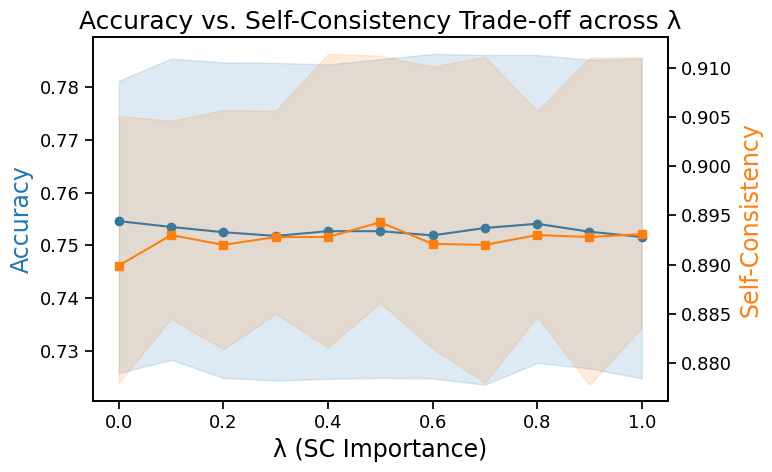

In [0]:
summary = combined_results_df.groupby("SC-Imp").agg(
    acc_mean=("Mean-Accuracy", "mean"),
    acc_q10=("Mean-Accuracy", lambda x: x.quantile(0.1)),
    acc_q90=("Mean-Accuracy", lambda x: x.quantile(0.9)),
    sc_mean=("Mean-SC", "mean"),
    sc_q10=("Mean-SC", lambda x: x.quantile(0.1)),
    sc_q90=("Mean-SC", lambda x: x.quantile(0.9)),
).reset_index()

fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.plot(summary["SC-Imp"], summary["acc_mean"], marker="o", color="tab:blue", label="Mean Accuracy")
ax1.fill_between(summary["SC-Imp"], summary["acc_q10"], summary["acc_q90"], color="tab:blue", alpha=0.15)
ax1.set_xlabel("λ (SC Importance)", fontsize=17)
ax1.set_ylabel("Accuracy", color="tab:blue", fontsize=17)
ax1.tick_params(axis="both", labelsize=13)

ax2 = ax1.twinx()
ax2.plot(summary["SC-Imp"], summary["sc_mean"], marker="s", color="tab:orange", label="Mean Self-Consistency")
ax2.fill_between(summary["SC-Imp"], summary["sc_q10"], summary["sc_q90"], color="tab:orange", alpha=0.15)
ax2.set_ylabel("Self-Consistency", color="tab:orange", fontsize=17)
ax2.tick_params(axis="y", labelsize=13)

plt.title("Accuracy vs. Self-Consistency Trade-off across λ", fontsize=18)
fig.tight_layout()
fig.savefig("german_credit_sc_vs_accuracy_forlam.png", dpi=300, bbox_inches="tight")
plt.show()

In [0]:
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
print(summary)

    SC-Imp  acc_mean  acc_q10  acc_q90  sc_mean  sc_q10  sc_q90
0   0.0000    0.7546   0.7258   0.7812   0.8899  0.8780  0.9051
1   0.1000    0.7535   0.7283   0.7854   0.8930  0.8845  0.9046
2   0.2000    0.7525   0.7249   0.7847   0.8920  0.8814  0.9057
3   0.3000    0.7518   0.7244   0.7846   0.8928  0.8850  0.9056
4   0.4000    0.7527   0.7247   0.7843   0.8928  0.8816  0.9114
5   0.5000    0.7527   0.7249   0.7853   0.8943  0.8861  0.9112
6   0.6000    0.7519   0.7248   0.7863   0.8921  0.8815  0.9101
7   0.7000    0.7533   0.7236   0.7861   0.8920  0.8780  0.9111
8   0.8000    0.7541   0.7277   0.7861   0.8930  0.8847  0.9056
9   0.9000    0.7526   0.7267   0.7852   0.8928  0.8778  0.9110
10  1.0000    0.7516   0.7248   0.7854   0.8931  0.8836  0.9111


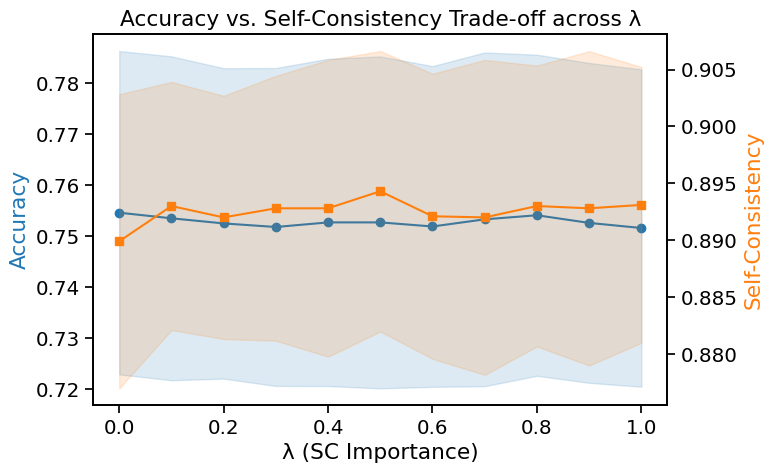

In [0]:
summary = combined_results_df.groupby("SC-Imp").agg(
    acc_mean=("Mean-Accuracy", "mean"),
    acc_std=("Mean-Accuracy", "std"),
    sc_mean=("Mean-SC", "mean"),
    sc_std=("Mean-SC", "std"),
).reset_index()

fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.plot(summary["SC-Imp"], summary["acc_mean"], marker="o", color="tab:blue", label="Mean Accuracy")
ax1.fill_between(summary["SC-Imp"], summary["acc_mean"] - summary["acc_std"], summary["acc_mean"] + summary["acc_std"], color="tab:blue", alpha=0.15)
ax1.set_xlabel("λ (SC Importance)")
ax1.set_ylabel("Accuracy", color="tab:blue")

ax2 = ax1.twinx()
ax2.plot(summary["SC-Imp"], summary["sc_mean"], marker="s", color="tab:orange", label="Mean Self-Consistency")
ax2.fill_between(summary["SC-Imp"], summary["sc_mean"] - summary["sc_std"], summary["sc_mean"] + summary["sc_std"], color="tab:orange", alpha=0.15)
ax2.set_ylabel("Self-Consistency", color="tab:orange")

plt.title("Accuracy vs. Self-Consistency Trade-off across λ")
fig.tight_layout()
fig.savefig("german_credit_sc_vs_accuracy_forlam.png", dpi=300, bbox_inches="tight")
plt.show()

In [0]:
weight_cols = [f"{v} (w)" for v in models_set.values()]  # ["LR (w)", "DT (w)", "RF (w)", "GB (w)"]

weight_summary = combined_results_df.groupby("SC-Imp")[weight_cols].mean().reset_index()

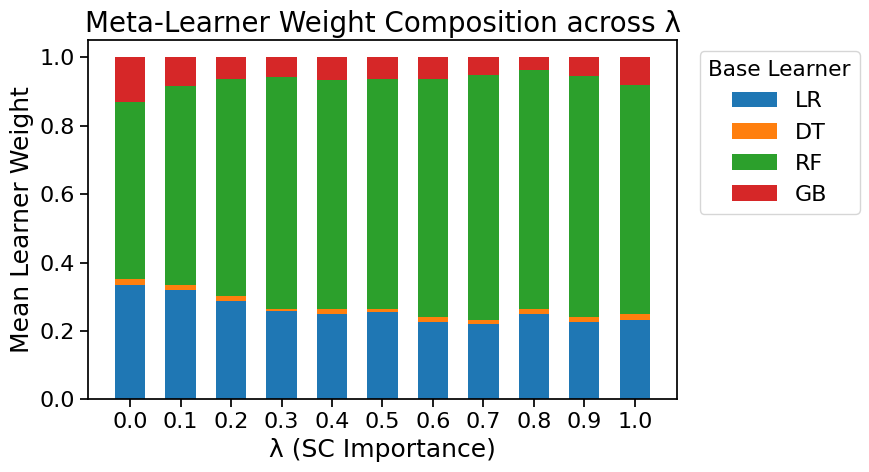

In [0]:
fig, ax = plt.subplots(figsize=(9, 5))

bottom = np.zeros(len(weight_summary))
colors = {"LR (w)": "tab:blue", "DT (w)": "tab:orange", "RF (w)": "tab:green", "GB (w)": "tab:red"}

for col in weight_cols:
    ax.bar(weight_summary["SC-Imp"].astype(str), weight_summary[col], bottom=bottom, label=col.replace(" (w)", ""), color=colors[col], width=0.6)
    bottom += weight_summary[col].values

ax.set_xlabel("λ (SC Importance)")
ax.set_ylabel("Mean Learner Weight")
ax.set_title("Meta-Learner Weight Composition across λ")
ax.legend(title="Base Learner", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig.savefig("german_credit_meta_learner_weights_for_lam.png", dpi=300, bbox_inches="tight")
plt.show()

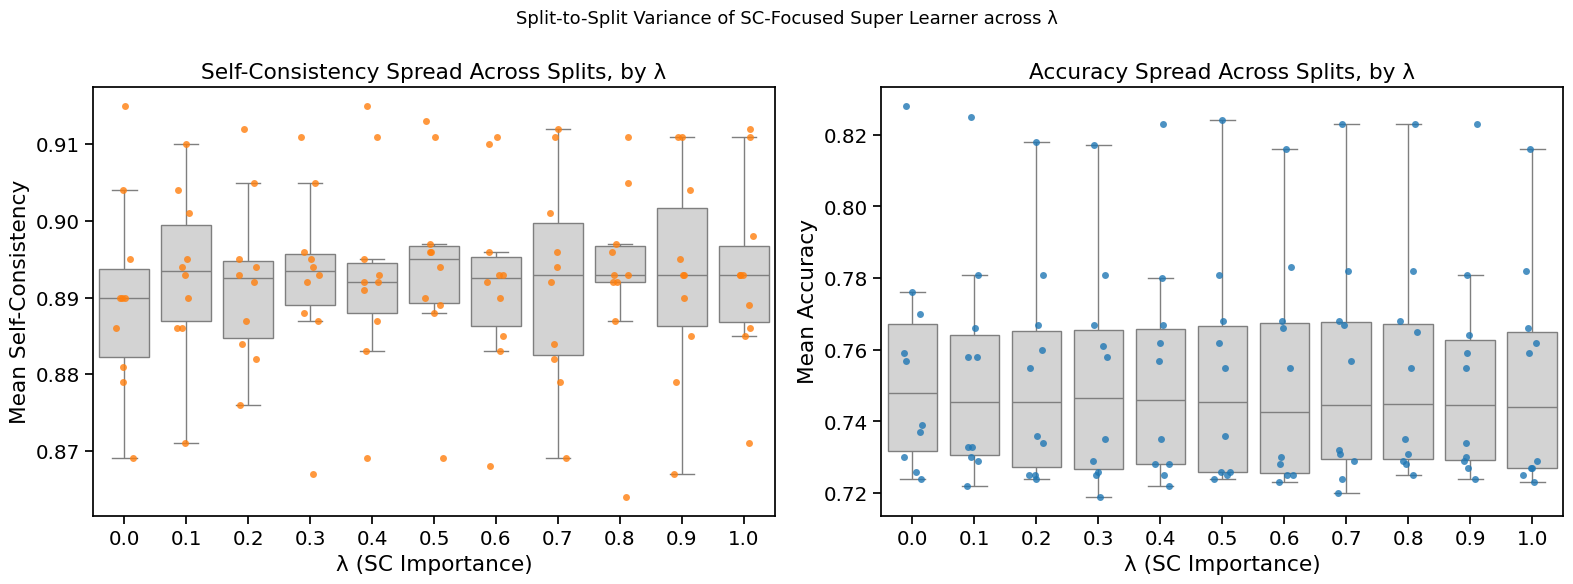

In [0]:
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Mean-SC across splits, faceted by lambda ---
sns.boxplot(data=combined_results_df, x="SC-Imp", y="Mean-SC", ax=axes[0], color="lightgray", fliersize=0)
sns.stripplot(data=combined_results_df, x="SC-Imp", y="Mean-SC", ax=axes[0], color="tab:orange", size=5, jitter=0.15, alpha=0.8)
axes[0].set_xlabel("λ (SC Importance)")
axes[0].set_ylabel("Mean Self-Consistency")
axes[0].set_title("Self-Consistency Spread Across Splits, by λ")

# --- Mean-Accuracy across splits, faceted by lambda ---
sns.boxplot(data=combined_results_df, x="SC-Imp", y="Mean-Accuracy", ax=axes[1], color="lightgray", fliersize=0)
sns.stripplot(data=combined_results_df, x="SC-Imp", y="Mean-Accuracy", ax=axes[1], color="tab:blue", size=5, jitter=0.15, alpha=0.8)
axes[1].set_xlabel("λ (SC Importance)")
axes[1].set_ylabel("Mean Accuracy")
axes[1].set_title("Accuracy Spread Across Splits, by λ")

fig.suptitle("Split-to-Split Variance of SC-Focused Super Learner across λ", fontsize=13)
fig.tight_layout()
fig.savefig("german_credit_sc_accuracy_boxplot_for_lam.png", dpi=300, bbox_inches="tight")
plt.show()

In [0]:
sc_cols = ["SC (LR)", "SC (DT)", "SC (RF)", "SC (GB)"]
acc_cols = ["Acc (LR)", "Acc (DT)", "Acc (RF)", "Acc (GB)"]

# Individual learners: average across splits (same for every lambda, so just take lambda=0 rows)
indiv = combined_results_df[combined_results_df["SC-Imp"] == 0][sc_cols + acc_cols].mean()

# Meta-learner: average across splits, at each lambda you want to show
meta = combined_results_df.groupby("SC-Imp")[["Mean-SC", "Mean-Accuracy"]].mean().reset_index()

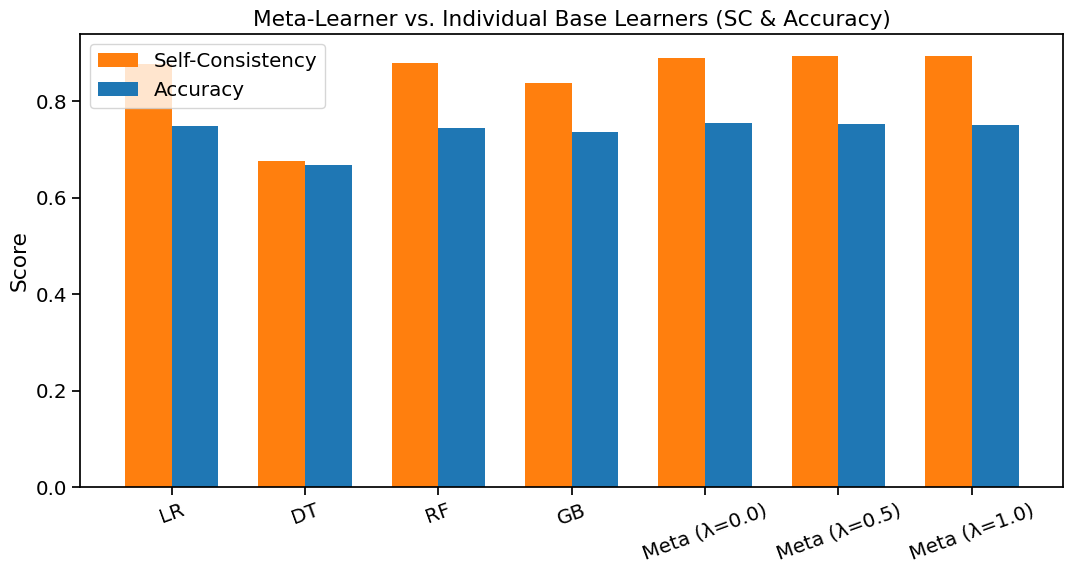

In [0]:
learners = ["LR", "DT", "RF", "GB"]
meta_lambdas = [0.0, 0.5, 1.0]

labels = learners + [f"Meta (λ={l})" for l in meta_lambdas]
sc_values = [indiv[f"SC ({l})"] for l in learners] + [meta.loc[meta["SC-Imp"] == l, "Mean-SC"].values[0] for l in meta_lambdas]
acc_values = [indiv[f"Acc ({l})"] for l in learners] + [meta.loc[meta["SC-Imp"] == l, "Mean-Accuracy"].values[0] for l in meta_lambdas]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(x - width/2, sc_values, width, label="Self-Consistency", color="tab:orange")
ax.bar(x + width/2, acc_values, width, label="Accuracy", color="tab:blue")

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20)
ax.set_ylabel("Score")
ax.set_title("Meta-Learner vs. Individual Base Learners (SC & Accuracy)")
ax.legend()
fig.tight_layout()
fig.savefig("german_credit_super_learner_vs_individual_learner_for_lam.png", dpi=300, bbox_inches="tight")
plt.show()

In [0]:
import time
 
minute = 20
for i in range(minute):    
    print(f"Spark heartbeat {i+1}")
    time.sleep(60)
    i = i+1

Spark heartbeat 1
Spark heartbeat 2
Spark heartbeat 3
Spark heartbeat 4
Spark heartbeat 5
Spark heartbeat 6
Spark heartbeat 7
Spark heartbeat 8
Spark heartbeat 9
Spark heartbeat 10
Spark heartbeat 11


### Meta vs Individual SC for Classical Super Learner and SC-Focused Super Learner

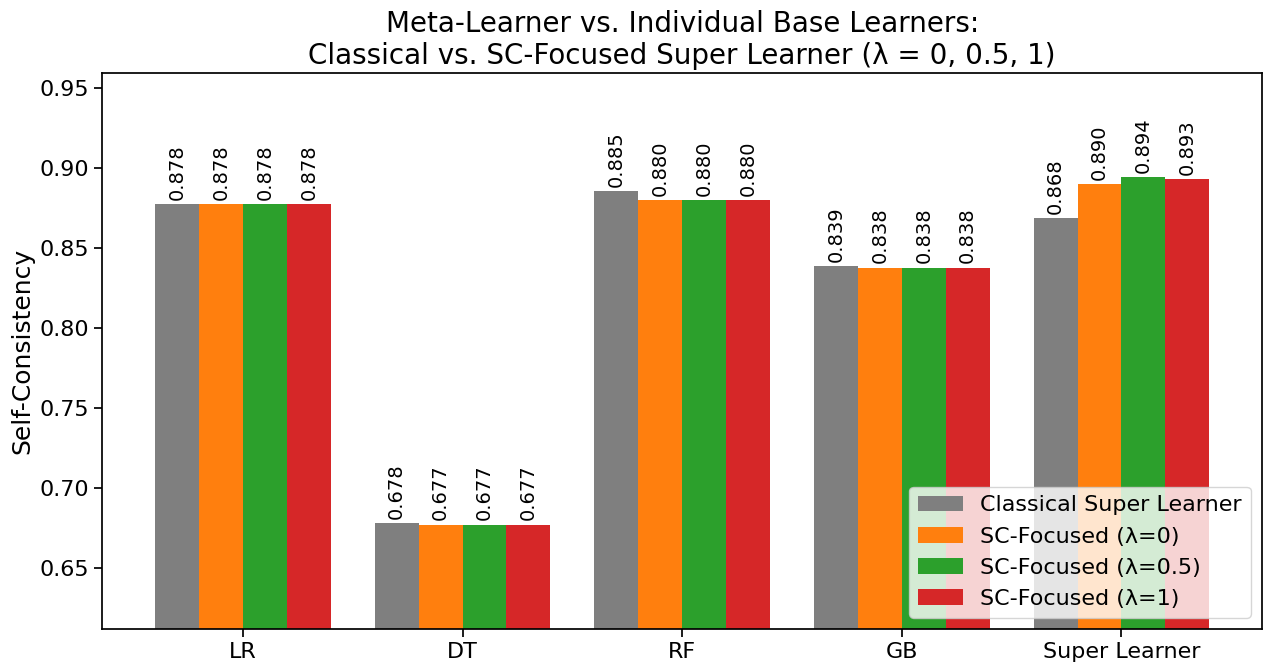

In [0]:
# Step 1 — Classical
plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
})
# Step 1 — Classical
classical_dedup = combined_classical_df.groupby("outer_split").first().reset_index()
classical_sc = {
    "Super Learner": classical_dedup["Meta Learner SC"].mean(),
    "LR": classical_dedup["Logistic Regression SC"].mean(),
    "DT": classical_dedup["Decision Tree SC"].mean(),
    "RF": classical_dedup["Random Forest SC"].mean(),
    "GB": classical_dedup["Gradient Boosting SC"].mean(),
}

# Step 2 — SC-Focused, one dict per lambda
def get_sc_focused_values(lam):
    subset = combined_results_df[combined_results_df["SC-Imp"] == lam]
    return {
        "Super Learner": subset["Mean-SC"].mean(),
        "LR": subset["SC (LR)"].mean(),
        "DT": subset["SC (DT)"].mean(),
        "RF": subset["SC (RF)"].mean(),
        "GB": subset["SC (GB)"].mean(),
    }

sc_focused_0 = get_sc_focused_values(0)
sc_focused_05 = get_sc_focused_values(0.5)
sc_focused_1 = get_sc_focused_values(1)

# Step 3 — Grouped bar chart, 4 bars per learner
learners = ["LR", "DT", "RF", "GB", "Super Learner"]
series = {
    "Classical Super Learner": [classical_sc[l] for l in learners],
    "SC-Focused (λ=0)": [sc_focused_0[l] for l in learners],
    "SC-Focused (λ=0.5)": [sc_focused_05[l] for l in learners],
    "SC-Focused (λ=1)": [sc_focused_1[l] for l in learners],
}
colors = ["tab:gray", "tab:orange", "tab:green", "tab:red"]

x = np.arange(len(learners))
n_series = len(series)
width = 0.8 / n_series  # total group width 0.8, split across bars

fig, ax = plt.subplots(figsize=(13, 7))
all_values = []
for i, (label, values) in enumerate(series.items()):
    offset = (i - (n_series - 1) / 2) * width
    bars = ax.bar(x + offset, values, width, label=label, color=colors[i])
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=14, rotation=90)
    all_values.extend(values)

# Scale y-axis to the data range instead of starting at 0
y_min, y_max = min(all_values), max(all_values)
padding = (y_max - y_min) * 0.3 if y_max > y_min else 0.02
ax.set_ylim(max(0, y_min - padding), min(1.05, y_max + padding))

ax.set_xticks(x)
ax.set_xticklabels(learners)
ax.set_ylabel("Self-Consistency")
ax.set_title(
    "Meta-Learner vs. Individual Base Learners:\n"
    "Classical vs. SC-Focused Super Learner (λ = 0, 0.5, 1)"
)
ax.legend(loc="lower right")
fig.tight_layout()

fig.savefig("german_credit_classical_vs_sc_focused_learners_sc_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

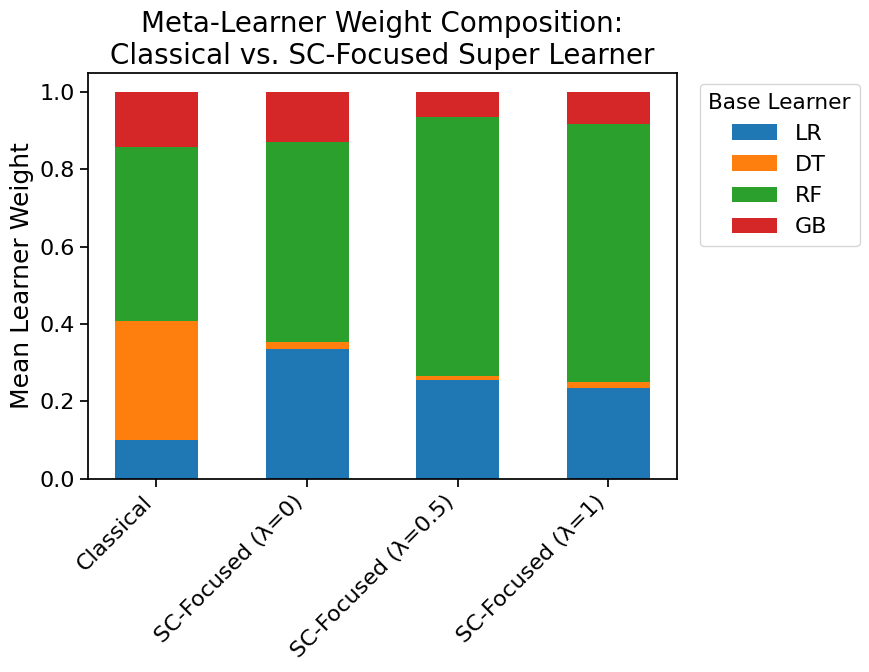

In [0]:
models_types = ["Logistic Regression", "Random Forest", "Decision Tree", "Gradient Boosting"]
models_set = {"Logistic Regression" : "LR", "Decision Tree" : "DT", "Random Forest" : "RF", "Gradient Boosting" : "GB"}

name_to_abbrev = models_set

classical_weight_means = combined_classical_df[[f"{m} (w)" for m in name_to_abbrev.keys()]].mean()
classical_weight_means.index = [name_to_abbrev[c.replace(" (w)", "")] for c in classical_weight_means.index]

sc_focused_weight_cols = [f"{v} (w)" for v in models_set.values()]

def get_sc_focused_weights(lam):
    subset = combined_results_df[combined_results_df["SC-Imp"] == lam]
    means = subset[sc_focused_weight_cols].mean()
    means.index = [c.replace(" (w)", "") for c in means.index]
    return means

sc_focused_0 = get_sc_focused_weights(0)
sc_focused_05 = get_sc_focused_weights(0.5)
sc_focused_1 = get_sc_focused_weights(1)

weight_summary = pd.DataFrame({
    "Classical": classical_weight_means,
    "SC-Focused (λ=0)": sc_focused_0,
    "SC-Focused (λ=0.5)": sc_focused_05,
    "SC-Focused (λ=1)": sc_focused_1,
}).T

learners = weight_summary.columns.tolist()
colors = {learners[0]: "tab:blue", learners[1]: "tab:orange", learners[2]: "tab:green", learners[3]: "tab:red"}

fig, ax = plt.subplots(figsize=(9, 7))

bottom = np.zeros(len(weight_summary))
for learner in learners:
    values = weight_summary[learner].values
    ax.bar(weight_summary.index, values, bottom=bottom, label=learner, color=colors[learner], width=0.55)
    bottom += values

ax.set_ylabel("Mean Learner Weight")
ax.set_title("Meta-Learner Weight Composition:\nClassical vs. SC-Focused Super Learner")
ax.legend(title="Base Learner", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
fig.tight_layout()

fig.savefig("german_credit_classical_vs_sc_focused_weight_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [0]:
# Classical: accuracy columns are per-row (not pooled/broadcast), so average across all rows directly
classical_acc = {
    "LR": combined_classical_df["Logistic Regression accuracy"].mean(),
    "DT": combined_classical_df["Decision Tree accuracy"].mean(),
    "RF": combined_classical_df["Random Forest accuracy"].mean(),
    "GB": combined_classical_df["Gradient Boosting accuracy"].mean(),
    "Meta": combined_classical_df["Meta Model accuracy"].mean(),
}

# SC-Focused: average across the 10 splits, at each lambda
def get_sc_focused_acc(lam):
    subset = combined_results_df[combined_results_df["SC-Imp"] == lam]
    return {
        "LR": subset["Acc (LR)"].mean(),
        "DT": subset["Acc (DT)"].mean(),
        "RF": subset["Acc (RF)"].mean(),
        "GB": subset["Acc (GB)"].mean(),
        "Meta": subset["Mean-Accuracy"].mean(),
    }

sc_focused_acc_0 = get_sc_focused_acc(0)
sc_focused_acc_05 = get_sc_focused_acc(0.5)
sc_focused_acc_1 = get_sc_focused_acc(1)

accuracy_table = pd.DataFrame({
    "Classical": classical_acc,
    "SC-Focused (λ=0)": sc_focused_acc_0,
    "SC-Focused (λ=0.5)": sc_focused_acc_05,
    "SC-Focused (λ=1)": sc_focused_acc_1,
}).round(4)

accuracy_table = accuracy_table.loc[["LR", "DT", "RF", "GB", "Meta"]]  # fix row order

display(accuracy_table)

Classical,SC-Focused (λ=0),SC-Focused (λ=0.5),SC-Focused (λ=1)
0.7486,0.7486,0.7486,0.7486
0.6649,0.6672,0.6672,0.6672
0.7403,0.7452,0.7452,0.7452
0.7356,0.7353,0.7353,0.7353
0.7424,0.7546,0.7527,0.7516
